# B-Scan Migration Playground — Subwavelength PSF Resolution Analysis

**Purpose:** Quantify the lateral resolution limit of two subwavelength PEC point scatterers
using Point Spread Functions from a gprMax **zero-offset B-scan** simulation.

## Geometry
Unlike a Common Shot Gather (fixed source, receiver array), this notebook simulates a
**true zero-offset B-scan**: transmitter and receiver are co-located (1-cell offset) and
step together across the profile. Each column in the B-scan matrix represents one
independent zero-offset sounding at a unique lateral position.

The **exploding-reflector hypothesis** applies: reflections are treated as emitting upward
with half the medium velocity `v_mig = v/2`, so all three migration algorithms use this
half-velocity consistently.

## Migration methods (all post-stack / zero-offset)
| Method | Domain | Velocity use |
|--------|--------|---------------|
| Kirchhoff (delay-and-sum) | Time domain, trace-by-trace | `t = r / v_mig + t0` (hyperbolic DAS) |
| Gazdag Phase-Shift | Frequency-wavenumber (f-k) | `kz = √((ω/v_mig)² − kx²)`, depth stepping |
| Backpropagation (time reversal) | Time domain, analytic signal | `t = 2r/v` full two-way, complex coherent sum |

## Sensitivity sweep
With a varying spacing between two point scatterers (2 lambda to 1/16 lambda), measure the sensitivity after migration if two point spread functions (PSF's) can be resolved seperately

In [1]:
import os, time as _time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import os
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from gprMax.gprMax import api
from tools.outputfiles_merge import merge_files
from tools.plot_Bscan import get_output_data, mpl_plot

In [2]:
# ── Standard figure auto-save (protocol: .wiki/FIGURES_PROTOCOL.md) ─────────
import sys, pathlib
if str(pathlib.Path.cwd()) not in sys.path:
    sys.path.insert(0, str(pathlib.Path.cwd()))
from helper_functions.figures import setup_autosave
setup_autosave(study="Resolution_Study", prefix="RES_")


Figure autosave -> C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Figures\Resolution_Study  (prefix='RES_', dpi=300)


In [3]:
# ── Shared plotting helpers (see helper_functions/visualisation.py) ───────────────
from helper_functions.visualisation import (
    plot_domain_geometry, plot_bscan_grid, plot_migrated_grid, plot_wavefield_grid,
    plot_method_comparison_grid, plot_psf_grid, plot_spectrum_grid, plot_trace_comparison,
    COLOR_AMPLITUDE, COLOR_ENVELOPE
)


In [4]:
# Medium
eps_r      = 3.15
v_ice      = 0.299792458 / np.sqrt(eps_r)   # m/ns ≈ 0.16892
f_c_GHz    = 1.5                              # centre frequency [GHz]
wavelength = v_ice / f_c_GHz                  # m ≈ 0.1126
v_mig      = v_ice / 2                        # exploding-reflector half-velocity [m/ns]
t0_ns      = np.sqrt(2) / f_c_GHz            # Ricker peak delay [ns] ≈ 0.943

# Survey geometry
domain_x   = 4.0
n_traces   = 380
trace_step = 0.01   # m
rx_offset  = 0.1    # m (source-receiver offset in .in file)
x_traces   = (0.1 + rx_offset / 2) + np.arange(n_traces) * trace_step   # midpoints [m]

# Scatterer geometry (shared across all datasets)
x_centre        = domain_x / 2
y_surface       = 0.9                          # air-ice interface [m from bottom]
y_scatterer     = y_surface - wavelength * 6  # cylinder centre [m from bottom]
z_scatterer     = y_surface - y_scatterer     # depth below surface [m] ≈ 0.676
radius_scat     = wavelength / 40             # radius of cylinder (point scatterer approximation) [m] ≈ 0.0028
z_top           = z_scatterer - radius_scat   # depth to cylinder top (first reflection)

separations = np.array([2, 1, 0.5, 0.25, 0.125, 0.0625]) * wavelength
x_s1_all    = np.round(x_centre - separations / 2, 3)
x_s2_all    = np.round(x_centre + separations / 2, 3)
labels      = ['2λ', '1λ', '½λ', '¼λ', '⅛λ', '¹⁄₁₆λ']

# Migration depth grid
z_img = np.linspace(0.0, 0.8, 160)

# Paths
STUDY_ROOT = Path(r'C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\resolution_study')

print(f'λ_ice       = {wavelength*1e3:.1f} mm')
print(f'v_ice       = {v_ice:.5f} m/ns,  v_mig = {v_mig:.5f} m/ns')
print(f't0_ns       = {t0_ns:.3f} ns')
print(f'z_scatterer = {z_scatterer:.3f} m  (centre),  z_top = {z_top:.4f} m')
print(f'x_traces    : {x_traces[0]:.3f} → {x_traces[-1]:.3f} m  ({n_traces} traces)')

λ_ice       = 112.6 mm
v_ice       = 0.16891 m/ns,  v_mig = 0.08446 m/ns
t0_ns       = 0.943 ns
z_scatterer = 0.676 m  (centre),  z_top = 0.6728 m
x_traces    : 0.150 → 3.940 m  (380 traces)


# Input File Creation

## Calculate Geometry Factors

In [5]:
separation = np.array([2, 1, 1/2, 1/4, 1/8, 1/16]) * wavelength  # m

x_centre = domain_x / 2
x_scatterer_1 = np.round(x_centre - separation / 2, 3) # 6 locations
x_scatterer_2 = np.round(x_centre + separation / 2, 3) # 6 locations

# check if discretisation is sufficient for CFL
dx_required = (v_ice / 4.5) / 10 # 4 GHz is the highest frequency component in the Ricker wavelet
if 0.001 < dx_required:
    print(f"Discretisation is sufficiently small")
if radius_scat < dx_required:
    print(f"Scatterer radius is smaller than discretisation")

Discretisation is sufficiently small
Scatterer radius is smaller than discretisation


## Background model (no scatterers)

In [ ]:
%%writefile resolution_study/background/resolution_background.in

#title: GPR Resolution Study - background
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice


#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 background n
#messages: y

## 2 $\lambda$ separation

In [ ]:
%%writefile resolution_study/study_2lambda/resolution_2lambda.in

#title: GPR Resolution Study - 2 wavelength separation
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Two point scatterers (PEC)
#cylinder: 1.887 0.224 0 1.887 0.224 0.001 0.0028 pec
#cylinder: 2.113 0.224 0 2.113 0.224 0.001 0.0028 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 two_point_scatterers_2_lambda n
#messages: y

## 1 $\lambda$ separation

In [ ]:
%%writefile resolution_study/study_1lambda/resolution_1lambda.in

#title: GPR Resolution Study - 1 wavelength separation
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Two point scatterers (PEC)
#cylinder: 1.944 0.224 0 1.944 0.224 0.001 0.0028 pec
#cylinder: 2.056 0.224 0 2.056 0.224 0.001 0.0028 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 two_point_scatterers_1_lambda n
#messages: y

## 1/2 $\lambda$ separation

In [ ]:
%%writefile resolution_study/study_0p5lambda/resolution_0p5lambda.in

#title: GPR Resolution Study - 0.5 wavelength separation
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Two point scatterers (PEC)
#cylinder: 1.972 0.224 0 1.972 0.224 0.001 0.0028 pec
#cylinder: 2.028 0.224 0 2.028 0.224 0.001 0.0028 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 two_point_scatterers_0p5_lambda n
#messages: y

## 1/4 $\lambda$ separation

In [ ]:
%%writefile resolution_study/study_0p25lambda/resolution_0p25lambda.in

#title: GPR Resolution Study - 0.25 wavelength separation
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Two point scatterers (PEC)
#cylinder: 1.986 0.224 0 1.986 0.224 0.001 0.0028 pec
#cylinder: 2.014 0.224 0 2.014 0.224 0.001 0.0028 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 two_point_scatterers_0p25_lambda n
#messages: y

## 1/8 $\lambda$ separation

In [ ]:
%%writefile resolution_study/study_0p125lambda/resolution_0p125lambda.in

#title: GPR Resolution Study - 0.125 wavelength separation
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Two point scatterers (PEC)
#cylinder: 1.993 0.224 0 1.993 0.224 0.001 0.0028 pec
#cylinder: 2.007 0.224 0 2.007 0.224 0.001 0.0028 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 two_point_scatterers_0p125_lambda n
#messages: y

## 1/16 $\lambda$ separation

In [ ]:
%%writefile resolution_study/study_0p0625lambda/resolution_0p0625lambda.in

#title: GPR Resolution Study - 0.0625 wavelength separation
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Two point scatterers (PEC)
#cylinder: 1.996 0.224 0 1.996 0.224 0.001 0.0028 pec
#cylinder: 2.004 0.224 0 2.004 0.224 0.001 0.0028 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 two_point_scatterers_0p0625_lambda n
#messages: y

## Ricker Wavelet Spectrum

  [saved] Resolution_Study\General\RES_001_Ricker_Wavelet_f_c__15_GHz_t0__0943_ns.png


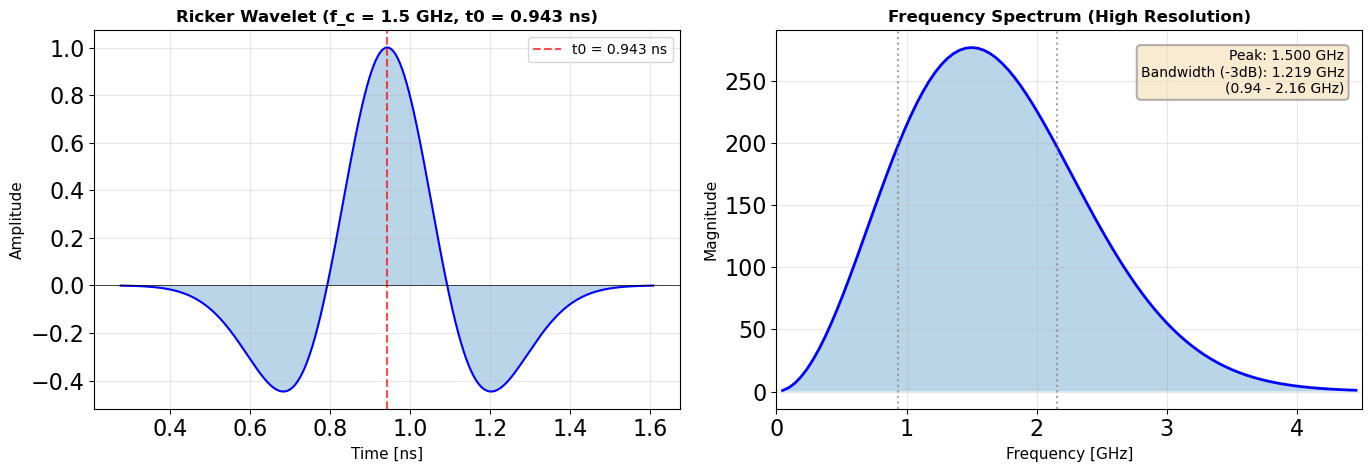

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Ricker wavelet parameters
f_c = 1.5e9  # Central frequency [Hz]
dt = 1e-12   # Time step [s] (1 ps for high frequency content)

# Generate Ricker wavelet with t0_ns time delay
t_max = 2 / f_c  # Duration covering 2 periods
n_samples = int(t_max / dt)
t = np.arange(n_samples) * dt - t_max/2

# Apply time delay
t_delayed = t + t0_ns * 1e-9

ricker = (1 - 2*(np.pi*f_c*t)**2) * np.exp(-(np.pi*f_c*t)**2)

# Compute frequency spectrum with zero-padding for higher resolution
n_fft = n_samples * 16  # 16x zero-padding for smoother spectrum
freqs = np.fft.rfftfreq(n_fft, dt)
spectrum = np.abs(np.fft.rfft(ricker, n=n_fft))

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Time domain
ax1.plot(t_delayed * 1e9, ricker, 'b-', linewidth=1.5)
ax1.fill_between(t_delayed * 1e9, ricker, alpha=0.3)
ax1.set_xlabel('Time [ns]', fontsize=11)
ax1.set_ylabel('Amplitude', fontsize=11)
ax1.set_title(f'Ricker Wavelet (f_c = {f_c/1e9:.1f} GHz, t0 = {t0_ns:.3f} ns)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axhline(0, color='k', linewidth=0.5)
ax1.axvline(t0_ns, color='r', linestyle='--', linewidth=1.5, alpha=0.7, label=f't0 = {t0_ns:.3f} ns')
ax1.legend(fontsize=10)

# Frequency domain (linear scale, high resolution)
freq_mask = (freqs > 0.0e9) & (freqs < 4.5e9)
ax2.plot(freqs[freq_mask] / 1e9, spectrum[freq_mask], 'b-', linewidth=2)
ax2.fill_between(freqs[freq_mask] / 1e9, spectrum[freq_mask], alpha=0.3)
ax2.set_xlabel('Frequency [GHz]', fontsize=11)
ax2.set_ylabel('Magnitude', fontsize=11)
ax2.set_title(f'Frequency Spectrum (High Resolution)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')
ax2.set_xlim([0.0, 4.5])

# Find peak and -3dB bandwidth
peak_idx = np.argmax(spectrum)
peak_freq = freqs[peak_idx]
spectrum_db = 20 * np.log10(spectrum / spectrum.max() + 1e-10)
peak_db = spectrum_db[peak_idx]
half_power_idx = np.where(spectrum_db >= peak_db - 3)[0]
if len(half_power_idx) > 0:
    f_low = freqs[half_power_idx[0]]
    f_high = freqs[half_power_idx[-1]]
    bandwidth = f_high - f_low
    ax2.axvline(f_low/1e9, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
    ax2.axvline(f_high/1e9, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
    ax2.text(0.97, 0.95, 
             f'Peak: {peak_freq/1e9:.3f} GHz\nBandwidth (-3dB): {bandwidth/1e9:.3f} GHz\n({f_low/1e9:.2f} - {f_high/1e9:.2f} GHz)',
             transform=ax2.transAxes, fontsize=10,
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6, edgecolor='gray', linewidth=1.5))

plt.tight_layout()
plt.show()

# Visualising Model Geometry

  [saved] Resolution_Study\General\RES_002_Resolution_Study__Model_Geometry__domain_4010_m_Δx__1_mm_PML.png


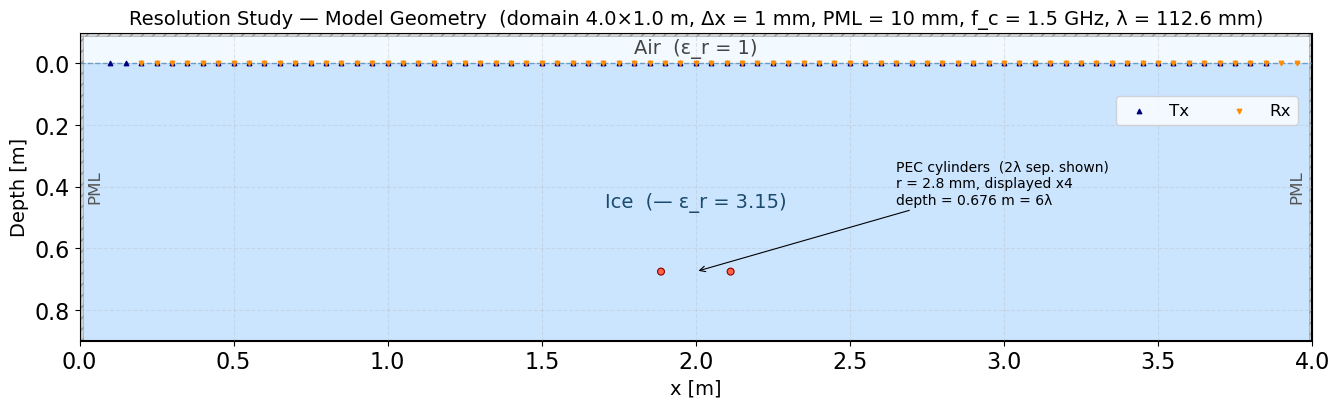

  [saved] Resolution_Study\General\RES_003_Scatterer_Positions__PEC_Cylinders__r__28_mm_depth__0676_m.png


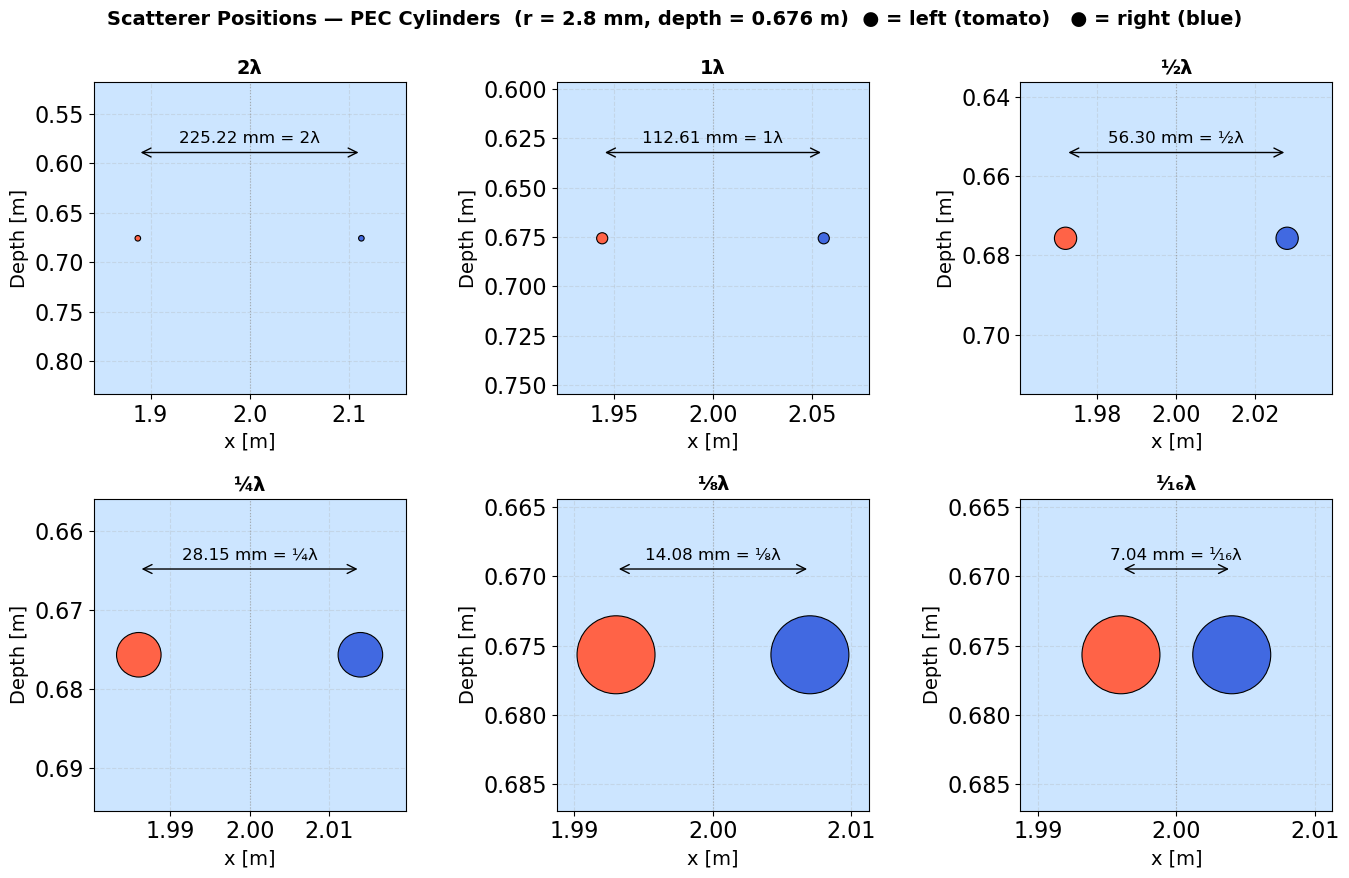

In [7]:
from matplotlib.patches import Rectangle, Circle
import matplotlib.pyplot as plt

# ── Geometry constants (from input files) ─────────────────────────────────────
# #domain: 4.000 1.000 0.001   →  domain_x × 1.0 m
# #dx_dy_dz: 0.001 0.001 0.001
# #pml_cells: 10 10 0 10 10 0  →  10 cells on x-min, x-max, y-max (not y-min)
# #box: 0 0 0 4.0 0.9 0.001 ice   →  ice fills 0–0.9 m in y; top 0.1 m is air
# #cylinder: xc 0.224 … r 0.0028  →  PEC scatterers, depth = z_scatterer below surface
# Tx at (curr_x, 0.900),  Rx at (curr_x + 0.100, 0.900)
domain_y  = 1.0           # m  gprMax y-extent
dx_grid   = 0.001         # m  grid cell size
pml_t     = 10 * dx_grid  # m  PML thickness  (10 cells = 10 mm)
air_h     = domain_y - y_surface    # = 0.1 m  air layer above ice surface
rx_off    = 0.1           # m  Tx-Rx offset (from input file)

# Depth coordinate: d = 0 at ice surface, d > 0 deeper, d < 0 above surface
d_top  = -air_h        # -0.1 m  top of gprMax domain
d_scat =  z_scatterer  #  0.676 m cylinder centre depth

# ── Figure 1: Full domain cross-section ──────────────────────────────────────
x_src_arr = 0.100 + np.arange(n_traces) * trace_step
fig1, ax1 = plot_domain_geometry(
    domain_x, domain_y, y_surface, pml_t,
    x_src=x_src_arr, rx_offset=rx_off, eps_r=eps_r, figsize=(14, 4)
)

# plot_domain_geometry's Air/Ice/PML text, in draw order -- bump their font size
# and nudge the PML labels off the domain border (pml_t is only 1 cm wide, so by
# default they sit almost exactly on x=0 / x=domain_x). Done here rather than in
# plot_domain_geometry itself since that function is shared across every notebook.
air_txt, ice_txt, pml_left, pml_right = ax1.texts[:4]
air_txt.set_fontsize(14)
ice_txt.set_fontsize(14)
pml_left.set_fontsize(12)
pml_right.set_fontsize(12)
pml_inset = 0.045  # [m] shift PML labels inward, off the border
pml_left.set_position((pml_t / 2 + pml_inset, pml_left.get_position()[1]))
pml_right.set_position((domain_x - pml_t / 2 - pml_inset, pml_right.get_position()[1]))

# PEC cylinders for 2-lambda scenario — radius exaggerated x4 for visibility
r_vis = 4 * radius_scat
for xc in [x_s1_all[0], x_s2_all[0]]:
    ax1.add_patch(Circle((xc, d_scat), r_vis,
                         facecolor='tomato', edgecolor='#800', lw=0.8, zorder=5))
ax1.annotate(
    f'PEC cylinders  (2λ sep. shown)\n'
    f'r = {radius_scat*1e3:.1f} mm, displayed x4\n'
    f'depth = {d_scat:.3f} m = {z_scatterer/wavelength:.0f}λ',
    xy=(x_centre, d_scat),
    xytext=(x_centre + 0.65, d_scat - 0.22),
    fontsize=10, ha='left',
    arrowprops=dict(arrowstyle='->', color='k', lw=0.8)
)

ax1.set_xlim(0, domain_x)
ax1.set_ylim(y_surface, d_top)   # depth increases downward
ax1.set_xlabel('x [m]', fontsize=14)
ax1.set_ylabel('Depth [m]', fontsize=14)
ax1.set_title(
    f'Resolution Study — Model Geometry  '
    f'(domain {domain_x:.1f}×{domain_y:.1f} m, '
    f'Δx = {dx_grid*1e3:.0f} mm, PML = {pml_t*1e3:.0f} mm, '
    f'f_c = {f_c_GHz} GHz, λ = {wavelength*1e3:.1f} mm)',
    fontsize=14
)
ax1.set_aspect('equal', adjustable='box')
ax1.legend(loc='upper right', fontsize=12, ncol=2, bbox_to_anchor=(0.995, 0.82))
ax1.grid(True, ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

# ── Figure 2: Zoomed scatterer positions for each separation scenario ─────────
fig2, axes2 = plt.subplots(2, 3, figsize=(14, 9))

for ax, sep, x1, x2, lbl in zip(axes2.ravel(), separations, x_s1_all, x_s2_all, labels):
    hw = max(sep * 0.70, 4 * radius_scat)  # adaptive half-window

    # Ice background
    ax.add_patch(Rectangle((x_centre - hw, d_scat - hw), 2 * hw, 2 * hw,
                            facecolor='#cce5ff', edgecolor='#aac', lw=0.5))

    # Left cylinder (tomato) and right cylinder (royalblue)
    ax.add_patch(Circle((x1, d_scat), radius_scat,
                        facecolor='tomato',    edgecolor='black', lw=0.8, zorder=5))
    ax.add_patch(Circle((x2, d_scat), radius_scat,
                        facecolor='royalblue', edgecolor='black', lw=0.8, zorder=5))

    # Centre dashed line
    ax.axvline(x_centre, color='grey', lw=0.8, ls=':', alpha=0.5)

    # Separation annotation arrow above the cylinders
    y_ann = d_scat - hw * 0.55
    ax.annotate('', xy=(x2, y_ann), xytext=(x1, y_ann),
                arrowprops=dict(arrowstyle='<->', color='black', lw=1.0))
    ax.text(x_centre, y_ann - hw * 0.04,
            f'{sep*1e3:.2f} mm = {lbl}',
            ha='center', va='bottom', fontsize=12)

    ax.set_xlim(x_centre - hw, x_centre + hw)
    ax.set_ylim(d_scat + hw, d_scat - hw)  # depth increases downward
    ax.set_title(lbl, fontsize=14, fontweight='bold')
    ax.set_xlabel('x [m]', fontsize=14)
    ax.set_ylabel('Depth [m]', fontsize=14)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, ls='--', alpha=0.3)

fig2.suptitle(
    f'Scatterer Positions — PEC Cylinders  '
    f'(r = {radius_scat*1e3:.1f} mm, depth = {z_scatterer:.3f} m)  '
    '● = left (tomato)   ● = right (blue)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()

# Generating Geometry Files and Merged B-scans
Only uncomment and run when necessary

In [ ]:
# input_lambda_2      = r'resolution_study/study_2lambda/resolution_2lambda.in'
# input_lambda_1      = r'resolution_study/study_1lambda/resolution_1lambda.in'
# input_lambda_0p5    = r'resolution_study/study_0p5lambda/resolution_0p5lambda.in'
# input_lambda_0p25   = r'resolution_study/study_0p25lambda/resolution_0p25lambda.in'
# input_lambda_0p125  = r'resolution_study/study_0p125lambda/resolution_0p125lambda.in'
# input_lambda_0p0625 = r'resolution_study/study_0p0625lambda/resolution_0p0625lambda.in'

# api(input_lambda_2, n=1, geometry_only=True)
# api(input_lambda_1, n=1, geometry_only=True)
# api(input_lambda_0p5, n=1, geometry_only=True)
# api(input_lambda_0p25, n=1, geometry_only=True)
# api(input_lambda_0p125, n=1, geometry_only=True)
# api(input_lambda_0p0625, n=1, geometry_only=True)


In [ ]:
# filename_background    = r'resolution_study/background/resolution_background'
# filename_lambda_2      = r'resolution_study/study_2lambda/resolution_2lambda'
# filename_lambda_1      = r'resolution_study/study_1lambda/resolution_1lambda'
# filename_lambda_0p5    = r'resolution_study/study_0p5lambda/resolution_0p5lambda'
# filename_lambda_0p25   = r'resolution_study/study_0p25lambda/resolution_0p25lambda'
# filename_lambda_0p125  = r'resolution_study/study_0p125lambda/resolution_0p125lambda'
# filename_lambda_0p0625 = r'resolution_study/study_0p0625lambda/resolution_0p0625lambda'

# merge_files(filename_background, removefiles=True)
# merge_files(filename_lambda_2, removefiles=True)
# merge_files(filename_lambda_1, removefiles=True)
# merge_files(filename_lambda_0p5, removefiles=True)
# merge_files(filename_lambda_0p25, removefiles=True)
# merge_files(filename_lambda_0p125, removefiles=True)
# merge_files(filename_lambda_0p0625, removefiles=True)


# Loading in the data and removing direct wave

In [8]:
rxnumber    = 1
rxcomponent = 'Ez'

output_background, dt = get_output_data(
    'resolution_study/background/resolution_background_merged.out', rxnumber, rxcomponent
)

_paths = [
    'resolution_study/study_2lambda/resolution_2lambda_merged.out',
    'resolution_study/study_1lambda/resolution_1lambda_merged.out',
    'resolution_study/study_0p5lambda/resolution_0p5lambda_merged.out',
    'resolution_study/study_0p25lambda/resolution_0p25lambda_merged.out',
    'resolution_study/study_0p125lambda/resolution_0p125lambda_merged.out',
    'resolution_study/study_0p0625lambda/resolution_0p0625lambda_merged.out',
]
raw_outputs = [get_output_data(p, rxnumber, rxcomponent)[0] for p in _paths]
outputs     = [r - output_background for r in raw_outputs]   # background-subtracted

dt_ns   = dt * 1e9
n_t     = outputs[0].shape[0]
time_ns = np.arange(n_t) * dt_ns

# Convenience lists for the visualisation cells below
data_pre = [('Background', output_background)] + list(zip(labels, raw_outputs))
data     = list(zip(labels, outputs))

print(f'dt = {dt_ns:.6f} ns,  n_t = {n_t},  t_max = {time_ns[-1]:.2f} ns')
print(f'Data shape (n_t × n_tr): {outputs[0].shape}  ({n_t} time samples × {n_traces} traces)')

dt = 0.002359 ns,  n_t = 8481,  t_max = 20.00 ns
Data shape (n_t × n_tr): (8481, 380)  (8481 time samples × 380 traces)


# Visualisation

  [saved] Resolution_Study\General\RES_004_GPR_B-Scans__Background_and_Separation_Models.png


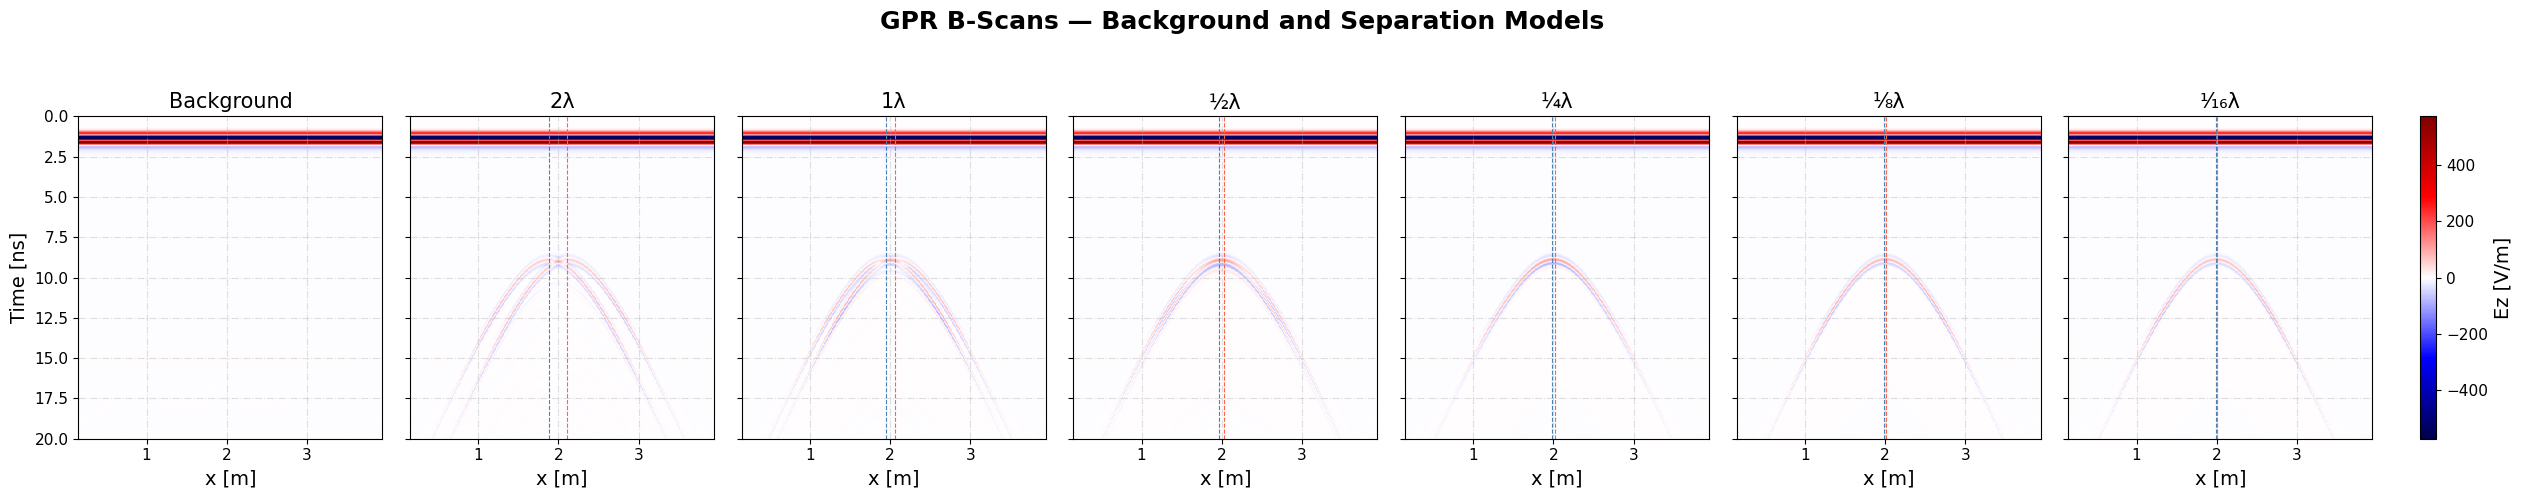

In [9]:
extent_bscan = [x_traces[0], x_traces[-1], time_ns[-1], 0]

def _make_sep_marker(sep_idx):
    """Dashed vertical lines at the two scatterer positions, matching the PSF
    zoom cell's colour convention (steelblue = left/scatterer 1, tomato =
    right/scatterer 2)."""
    def _marker(ax, i):
        ax.axvline(x_s1_all[sep_idx], color=COLOR_AMPLITUDE, lw=0.8, ls='--')
        ax.axvline(x_s2_all[sep_idx], color=COLOR_ENVELOPE, lw=0.8, ls='--')
    return _marker

markers_res004 = [None] + [_make_sep_marker(j) for j in range(len(x_s1_all))]

# plot_bscan_grid is shared across every notebook, so its module-level
# FONTSIZE constants are monkey-patched only around this call, then restored.
import helper_functions.visualisation as _viz
_orig_fs = (_viz.SUPTITLE_FONTSIZE, _viz.TITLE_FONTSIZE, _viz.LABEL_FONTSIZE)
_viz.SUPTITLE_FONTSIZE, _viz.TITLE_FONTSIZE, _viz.LABEL_FONTSIZE = 18, 15, 14
try:
    fig, axes = plot_bscan_grid(
        data_pre, x_traces, time_ns,
        title='GPR B-Scans — Background and Separation Models', figsize=(25, 5),
        markers=markers_res004,
    )
finally:
    _viz.SUPTITLE_FONTSIZE, _viz.TITLE_FONTSIZE, _viz.LABEL_FONTSIZE = _orig_fs
for ax in axes:
    ax.tick_params(labelsize=11)
cbar_ax = fig.axes[-1]   # colorbar axes, appended after the B-scan panels
cbar_ax.yaxis.label.set_fontsize(14)
cbar_ax.tick_params(labelsize=11)
plt.show()

  [saved] Resolution_Study\General\RES_005_GPR_B-Scans__Background_Subtracted.png


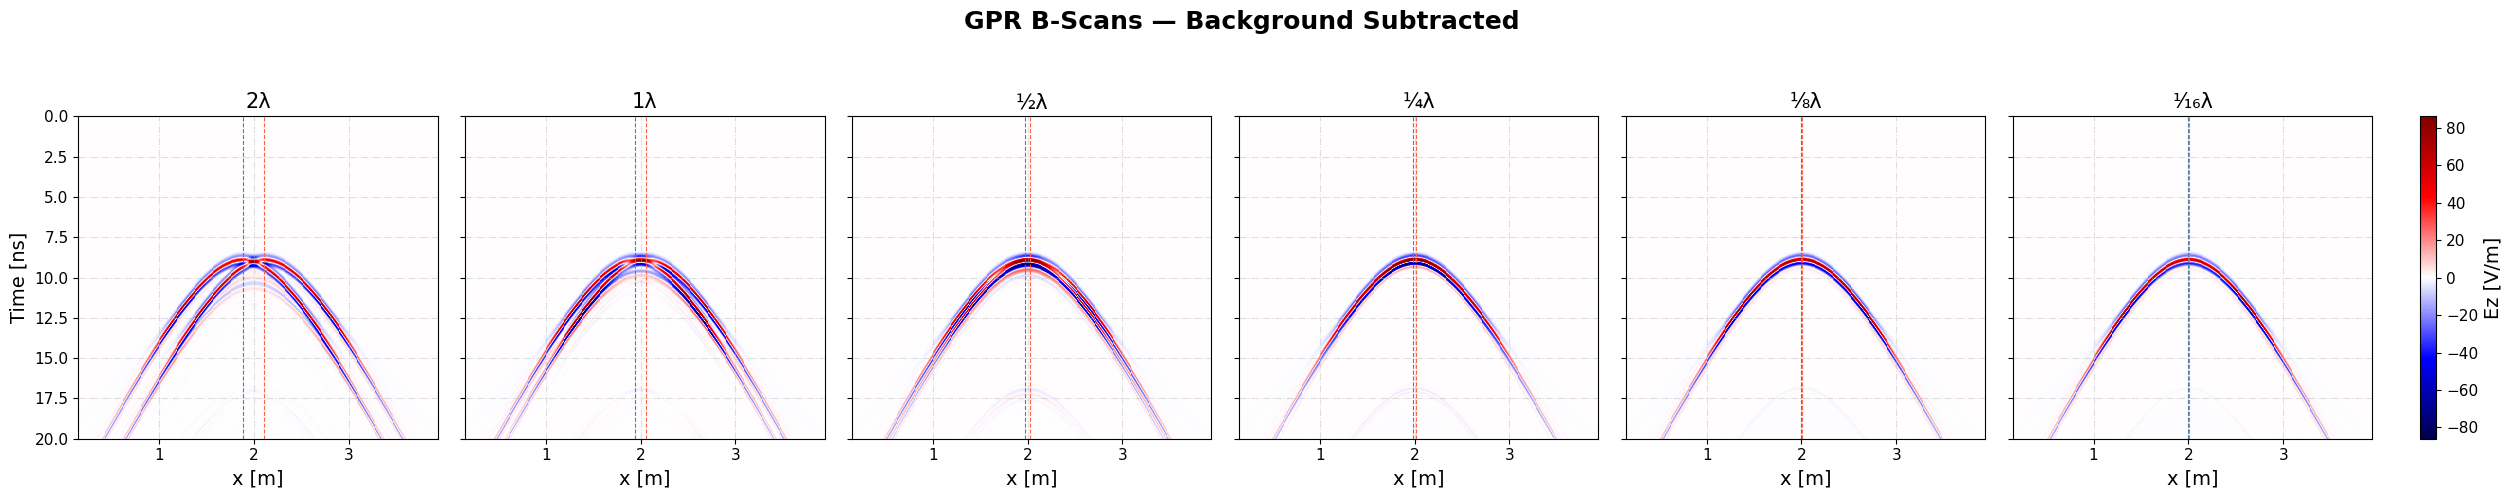

In [10]:
markers_res005 = [_make_sep_marker(j) for j in range(len(x_s1_all))]

# plot_bscan_grid is shared across every notebook, so its module-level
# FONTSIZE constants are monkey-patched only around this call, then restored.
import helper_functions.visualisation as _viz
_orig_fs = (_viz.SUPTITLE_FONTSIZE, _viz.TITLE_FONTSIZE, _viz.LABEL_FONTSIZE)
_viz.SUPTITLE_FONTSIZE, _viz.TITLE_FONTSIZE, _viz.LABEL_FONTSIZE = 18, 15, 14
try:
    fig, axes = plot_bscan_grid(
        data, x_traces, time_ns,
        title='GPR B-Scans — Background Subtracted', figsize=(25, 5),
        markers=markers_res005,
    )
finally:
    _viz.SUPTITLE_FONTSIZE, _viz.TITLE_FONTSIZE, _viz.LABEL_FONTSIZE = _orig_fs
for ax in axes:
    ax.tick_params(labelsize=11)
cbar_ax = fig.axes[-1]   # colorbar axes, appended after the B-scan panels
cbar_ax.yaxis.label.set_fontsize(14)
cbar_ax.tick_params(labelsize=11)
plt.show()

# Kirchhoff Migration

Delay-and-sum migration via the **PyLops zero-offset Kirchhoff operator**.  
Each dataset is preprocessed (tapering + t0 shift — see cell above) before being migrated.  
Green stars mark the true cylinder-top positions.

In [11]:
import sys, pathlib
_here = pathlib.Path.cwd()
if str(_here) not in sys.path:
    sys.path.insert(0, str(_here))
from helper_functions.migration import PylopsKirchoffMigration, gazdag_migration, write_backprop_files

## Tapering & t0 Shift

Two pre-processing steps applied to every B-scan before migration:

| Step | Purpose |
|------|---------|
| **Exponential decay taper** (`taper_decay_ns`) | Suppresses late arrivals, emphasises hyperbola apices |
| **Cosine end taper** (`taper_end_ns`) | Zeros the final portion of each trace to remove hyperbola tails |
| **t0 shift** | Removes the Ricker wavelet's built-in peak delay so that t = 0 aligns with the surface |

Adjust the parameters in the cell below and re-run to see their effect on the B-scan.

  [saved] Resolution_Study\General\RES_006_Effect_of_Tapering_and_t0_Shift__2λ_dataset_single_trace.png


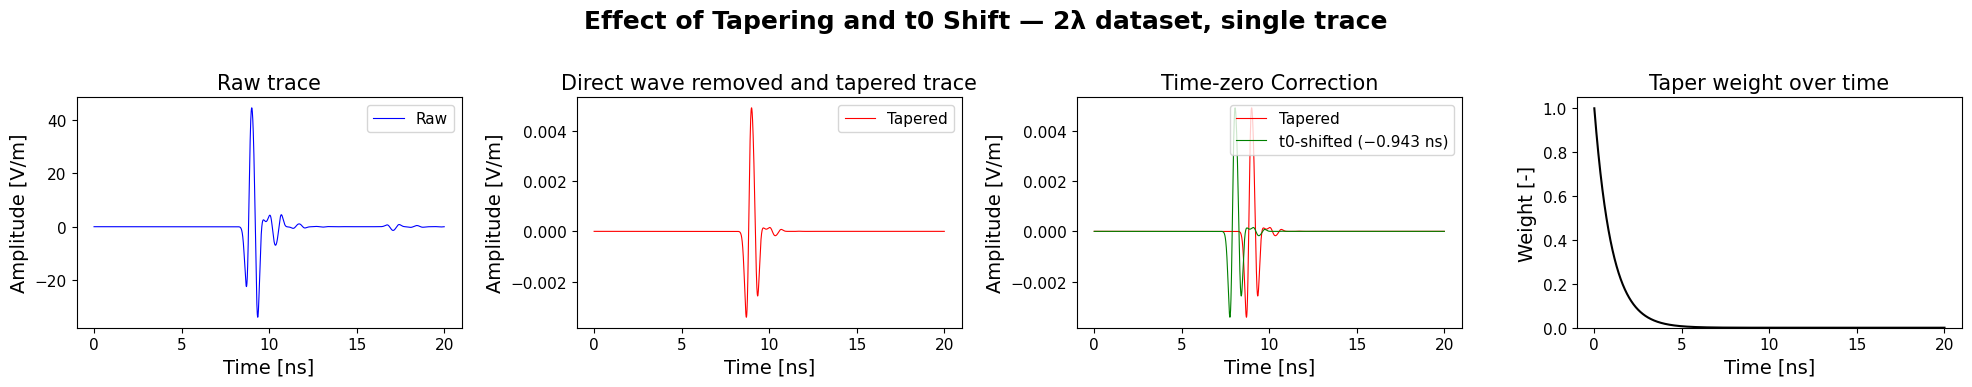

  [saved] Resolution_Study\General\RES_007_B-scan_effect_of_tapering_and_t0_shift__2λ_dataset.png


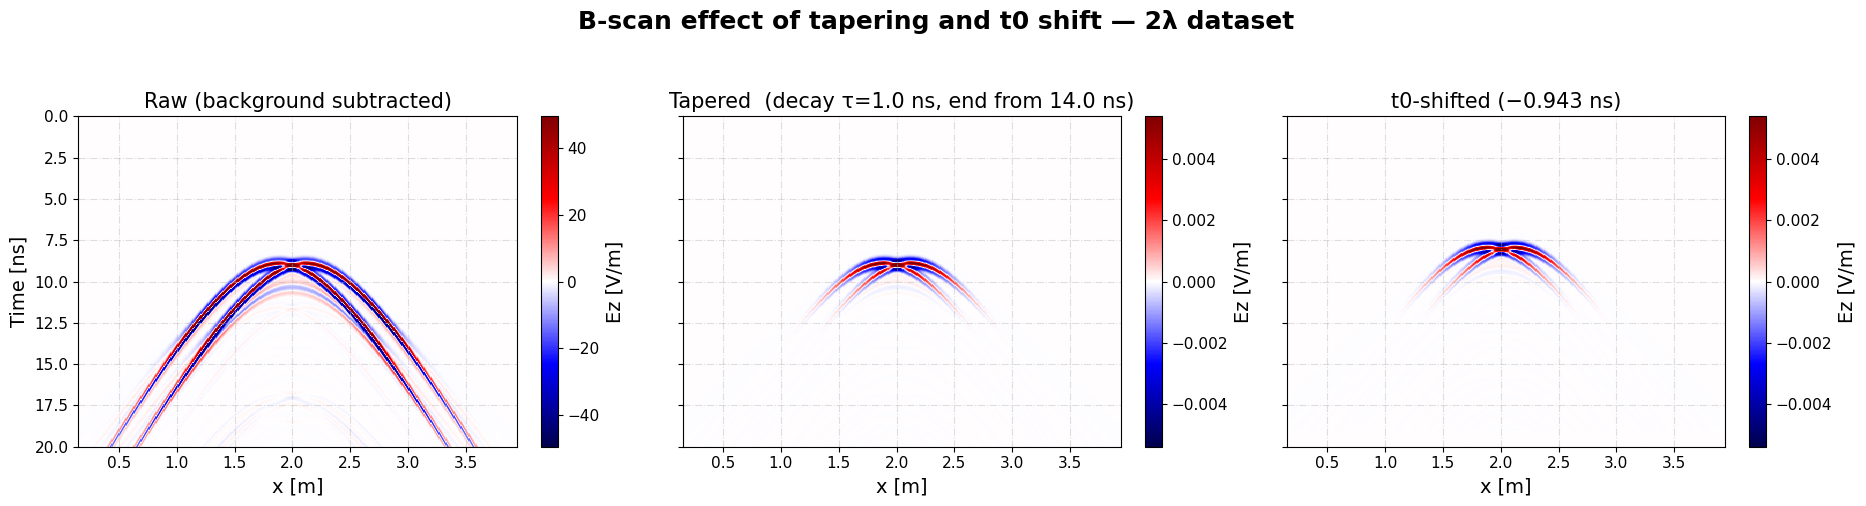

In [12]:
# ── Taper & t0-shift parameters ───────────────────────────────────────────────
taper_end_ns   = 14.0   # cosine ramp onset [ns]: zeros hyperbola tails beyond this time
taper_decay_ns = 1.0    # exponential decay time constant [ns]: de-emphasises late arrivals
ANGLE_AP       = 40     # Kirchhoff aperture half-angle [degrees]

# ── Functions ─────────────────────────────────────────────────────────────────
def make_end_taper(n_samples, taper_samples):
    """Unity everywhere, then half-cosine 1→0 over the last `taper_samples`."""
    win = np.ones(n_samples)
    if taper_samples > 0:
        ramp = 0.5 * (1 + np.cos(np.pi * np.arange(taper_samples) / taper_samples))
        win[-taper_samples:] = ramp
    return win

def make_decay_taper(time_ns, tau_ns):
    """Exponential decay starting at 1.0 (t=0) with time constant tau_ns."""
    return np.exp(-time_ns / tau_ns)

def preprocess(data_nt_ntr, dt_ns, t0_ns, time_ns):
    """
    Prepare a B-scan for Kirchhoff migration.
    Input:  data_nt_ntr  (n_t, n_tr)  — background-subtracted B-scan
    Returns tapered (n_tr, n_t) and t0-shifted (n_tr, n_t) arrays.
    """
    bscan   = data_nt_ntr.T.copy()                              # → (n_tr, n_t)
    n_t     = bscan.shape[1]
    w_end   = make_end_taper(n_t, int(round(taper_end_ns / dt_ns)))
    w_decay = make_decay_taper(time_ns, taper_decay_ns)
    tapered = bscan * (w_end * w_decay)[np.newaxis, :]
    t0_samp = int(round(t0_ns / dt_ns))
    shifted = np.roll(tapered, -t0_samp, axis=1)
    shifted[:, -t0_samp:] = 0.0
    return tapered, shifted

# ── Visualise effect on the 2λ dataset ────────────────────────────────────────
_demo = outputs[0]    # (n_t, n_tr)
_raw_tr, _shifted = preprocess(_demo, dt_ns, t0_ns, time_ns)
_tapered = _raw_tr   # preprocess returns tapered as first output

w_end_vis   = make_end_taper(n_t, int(round(taper_end_ns   / dt_ns)))
w_decay_vis = make_decay_taper(time_ns, taper_decay_ns)
taper_combined = w_end_vis * w_decay_vis

mid_tr = n_traces // 2   # representative central trace

# --- Row 1: single-trace before/after ---
# Raw and tapered are shown in separate panels (rather than overlaid) because
# the taper barely touches the trace before taper_end_ns, so an overlay makes
# the tapered curve invisible under the raw one; a 4th panel keeps the
# time-zero correction and taper-weight panels from the original 3-panel layout.
from helper_functions.visualisation import LABEL_FONTSIZE, LEGEND_FONTSIZE, TITLE_FONTSIZE, SUPTITLE_FONTSIZE
# Local overrides for this cell's figures only (not the shared module defaults,
# which every other notebook/cell reading these same names still gets).
TITLE_FONTSIZE, LABEL_FONTSIZE, LEGEND_FONTSIZE, SUPTITLE_FONTSIZE = 15, 14, 11, 18
TICK_FONTSIZE_LOCAL = 11

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].plot(time_ns, _demo[:, mid_tr], 'b', lw=0.8, label='Raw')
axes[0].set_title('Raw trace', fontsize=TITLE_FONTSIZE)
axes[0].set_xlabel('Time [ns]', fontsize=LABEL_FONTSIZE)
axes[0].set_ylabel('Amplitude [V/m]', fontsize=LABEL_FONTSIZE)
axes[0].legend(fontsize=LEGEND_FONTSIZE)

axes[1].plot(time_ns, _tapered[mid_tr], 'r', lw=0.8, label='Tapered')
axes[1].set_title('Direct wave removed and tapered trace', fontsize=TITLE_FONTSIZE)
axes[1].set_xlabel('Time [ns]', fontsize=LABEL_FONTSIZE)
axes[1].set_ylabel('Amplitude [V/m]', fontsize=LABEL_FONTSIZE)
axes[1].legend(fontsize=LEGEND_FONTSIZE)

axes[2].plot(time_ns, _tapered[mid_tr], 'r', lw=0.8, label='Tapered')
axes[2].plot(time_ns, _shifted[mid_tr], 'g', lw=0.8, label=f't0-shifted (−{t0_ns:.3f} ns)')
axes[2].set_title('Time-zero Correction', fontsize=TITLE_FONTSIZE)
axes[2].set_xlabel('Time [ns]', fontsize=LABEL_FONTSIZE)
axes[2].set_ylabel('Amplitude [V/m]', fontsize=LABEL_FONTSIZE)
axes[2].legend(fontsize=LEGEND_FONTSIZE)

axes[3].plot(time_ns, taper_combined, 'k', lw=1.5)
axes[3].set_title('Taper weight over time', fontsize=TITLE_FONTSIZE)
axes[3].set_ylim(0, 1.05)
axes[3].set_ylabel('Weight [-]', fontsize=LABEL_FONTSIZE)
axes[3].set_xlabel('Time [ns]', fontsize=LABEL_FONTSIZE)

for ax in axes:
    ax.tick_params(labelsize=TICK_FONTSIZE_LOCAL)

fig.suptitle('Effect of Tapering and t0 Shift — 2λ dataset, single trace',
             fontsize=SUPTITLE_FONTSIZE, fontweight='bold')
fig.tight_layout()
plt.show()

# --- Row 2: full B-scan comparison ---
# Bespoke (not plot_bscan_grid) because this panel needs its own independent
# colorbar per panel -- plot_bscan_grid only supports one shared colorbar
# (shared_colorbar=True) or none at all (False, the option this cell used
# before); adding a per-panel-colorbar mode to that shared function would
# change behaviour for every other notebook that calls it, so it stays local.
from helper_functions.visualisation import _resolve_vmax, CMAP_SIGNED, DEFAULT_VMAX_PERCENTILE

data_r2 = [
    ('Raw (background subtracted)', _demo),
    (f'Tapered  (decay τ={taper_decay_ns} ns, end from {taper_end_ns} ns)', _tapered.T),
    (f't0-shifted (−{t0_ns:.3f} ns)', _shifted.T),
]
extent_r2 = [x_traces[0], x_traces[-1], time_ns[-1], 0]
fig, axes = plt.subplots(1, 3, figsize=(19, 5), facecolor='w', sharey=True)
for ax, (panel_title, d) in zip(axes, data_r2):
    panel_vmax = _resolve_vmax(d, None, DEFAULT_VMAX_PERCENTILE, 0.5)   # vmax_headroom=0.5, matches the original call
    im = ax.imshow(d, aspect='auto', cmap=CMAP_SIGNED, extent=extent_r2,
                    interpolation='nearest', vmin=-panel_vmax, vmax=panel_vmax)
    ax.set_title(panel_title, fontsize=TITLE_FONTSIZE)
    ax.set_xlabel('x [m]', fontsize=LABEL_FONTSIZE)
    if ax is axes[0]:
        ax.set_ylabel('Time [ns]', fontsize=LABEL_FONTSIZE)
    ax.grid(linestyle='-.', alpha=0.4)
    ax.tick_params(labelsize=TICK_FONTSIZE_LOCAL)
    cb = fig.colorbar(im, ax=ax, fraction=0.046)
    cb.set_label('Ez [V/m]', fontsize=LABEL_FONTSIZE)
    cb.ax.tick_params(labelsize=TICK_FONTSIZE_LOCAL)
fig.suptitle('B-scan effect of tapering and t0 shift — 2λ dataset',
             fontsize=SUPTITLE_FONTSIZE, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

# Load Cached Results (optional shortcut)

This notebook has a narrower cache than its siblings: `resolution_study/migrated_results.npz` holds only the Kirchhoff and Gazdag migration grids for all 6 separation scenarios (plus a reprojected back-prop array and a single archived 2λ LSM/CGLS result). There is **no** raw-B-scan cache, **no** noisy-data cache, and **no** baseline/time-lapse-difference cache in this notebook (it studies two static-point-scatterer resolution, not time-lapse motion).

Run the setup/constants cells above and the **"Loading in the data and removing direct wave"** section (raw B-scans are not cached) plus the taper-parameter cell, then run this cell to skip straight to the Kirchhoff and Gazdag plotting cells below, bypassing their migration loops. The Back-Propagation section and the LSM/ILSM parameter-search section still need to be run from scratch if you need those results (see printed notes below for details).

In [13]:
USE_CACHED_RESULTS = True

if USE_CACHED_RESULTS:
    _mig = np.load(STUDY_ROOT / 'migrated_results.npz', allow_pickle=False)

    # ── Kirchhoff & Gazdag migration grids — directly reusable ────────────────
    # These are the two expensive, individually-timed migration loops (cells
    # under "Run Migration on All Datasets" for Kirchhoff and Gazdag below).
    # Reconstructing these two dicts is enough for both plotting cells and for
    # the Kirchhoff/Gazdag columns of the "Analysis" grid further down.
    migrated    = dict(zip(_mig['scenarios'], _mig['kirchhoff']))   # label -> (n_z, n_x)
    migrated_gz = dict(zip(_mig['scenarios'], _mig['gazdag']))      # label -> (n_z, n_x)

    # ── Back-propagation, reprojected onto the migration grid ─────────────────
    # Kept for reference/manual use only. NOT wired up automatically: the
    # "Analysis" cell (imgs[i][3]) has its own self-contained block that reads
    # the raw .vti wavefield snapshots straight off disk and reprojects them
    # itself -- it does not accept a pre-built array, so setting this variable
    # does not shortcut that block. In practice that block is cheap to (re)run
    # as long as the .vti snapshot files already exist under
    # resolution_study/backprop/<slug>/..._snaps/ (from a prior real run) --
    # it just needs `slugs`, `N_SNAP`, `SNAP_WIN` (plain constants defined at
    # the top of the "Back-Propagation Migration" section) and
    # `x_scatterer_1`/`x_scatterer_2` (defined in the early geometry cell) to
    # be in scope; it does NOT require re-running gprMax or the notebook's
    # snapshot-loading cell (`focus_frames`) that precedes it.
    backprop_all = _mig['backprop']   # (n_scenarios, n_z, n_x), scenario order = _mig['scenarios']

    # ── Archived single LSM (CGLS) result, 2λ scenario only ────────────────────
    # The "Analysis" cell picks up a variable literally named `m_cgls` via
    # `try: imgs[0][2] = m_cgls / except NameError: ...`, so defining it here
    # DOES let the Analysis grid's LSM column populate for the 2λ row without
    # re-running the CGLS/LSQR/FISTA regularization sweep — as long as you
    # don't also run the "Final LSM" section cells afterwards, which would
    # reassign `m_cgls` to a freshly (re)computed result.
    if 'lsm_cgls_2lambda' in _mig.files:
        m_cgls = _mig['lsm_cgls_2lambda']   # (n_z, n_x), 2λ scenario only

    extent_mig = [x_traces[0], x_traces[-1], z_img[-1], z_img[0]]

    print('Loaded cached migration results from', STUDY_ROOT / 'migrated_results.npz')
    print(f"  migrated     (Kirchhoff)  : {len(migrated)} scenarios, shape {next(iter(migrated.values())).shape}")
    print(f"  migrated_gz  (Gazdag)     : {len(migrated_gz)} scenarios, shape {next(iter(migrated_gz.values())).shape}")
    print(f"  backprop_all (reprojected): {backprop_all.shape}  (reference only, see note above)")
    if 'lsm_cgls_2lambda' in _mig.files:
        print(f"  m_cgls       (LSM, 2λ)    : {m_cgls.shape}  (2λ scenario only)")
    print()
    print('NOT covered by this cache (still need to run their notebook cells):')
    print('  - Raw B-scan loading ("Loading in the data and removing direct wave"): this')
    print('    notebook has no static_results-style cache — data_pre/data/outputs/time_ns/')
    print('    dt_ns/n_t must still come from that section, run it before this cell.')
    print('  - Back-Propagation Migration section (writes gprMax .in/excitation files + runs')
    print('    the simulation) — only needed if .vti snapshots are not already on disk; the')
    print('    Analysis cell reprojects them itself and does not need this cell to have run.')
    print('  - Least-Squares Migration (LSM) / Image-Domain LSM (ILSM) parameter sweeps')
    print('    (CGLS/LSQR-Tikhonov/FISTA + L-curve dashboard) — only a single archived 2λ')
    print('    CGLS result (m_cgls) is available from cache, not the full sweep.')
    print('  - There is no noisy-data pipeline and no baseline/time-lapse-difference concept')
    print('    in this notebook, so neither is reconstructed here.')


Loaded cached migration results from C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\resolution_study\migrated_results.npz
  migrated     (Kirchhoff)  : 6 scenarios, shape (160, 380)
  migrated_gz  (Gazdag)     : 6 scenarios, shape (160, 380)
  backprop_all (reprojected): (6, 160, 380)  (reference only, see note above)
  m_cgls       (LSM, 2λ)    : (160, 380)  (2λ scenario only)

NOT covered by this cache (still need to run their notebook cells):
  - Raw B-scan loading ("Loading in the data and removing direct wave"): this
    notebook has no static_results-style cache — data_pre/data/outputs/time_ns/
    dt_ns/n_t must still come from that section, run it before this cell.
  - Back-Propagation Migration section (writes gprMax .in/excitation files + runs
    the simulation) — only needed if .vti snapshots are not already on disk; the
    Analysis cell reprojects them itself and does not need this cell to have run.
  - Least-Squares Migration (LSM) / Image-Domain LSM (ILSM) p

## Run Migration on All Datasets

In [ ]:
# ── Kirchhoff migration on all 6 datasets ─────────────────────────────────────
migrated = {}

for label, raw in zip(labels, outputs):
    _, shifted = preprocess(raw, dt_ns, t0_ns, time_ns)   # (n_tr, n_t), t0-shifted
    print(f'[{label}] Running Kirchhoff ...', end=' ', flush=True)
    t0 = _time.perf_counter()
    img = PylopsKirchoffMigration(
        shifted, time_ns, x_traces, v_ice, z_img,
        f0=f_c_GHz, angleaperture=ANGLE_AP
    )
    print(f'{_time.perf_counter()-t0:.1f} s  shape={img.shape}')
    migrated[label] = img

  [saved] Resolution_Study\Kirchhoff\RES_008_Kirchhoff_Migration__All_Datasets____f_c15_GHz____aperture40.png


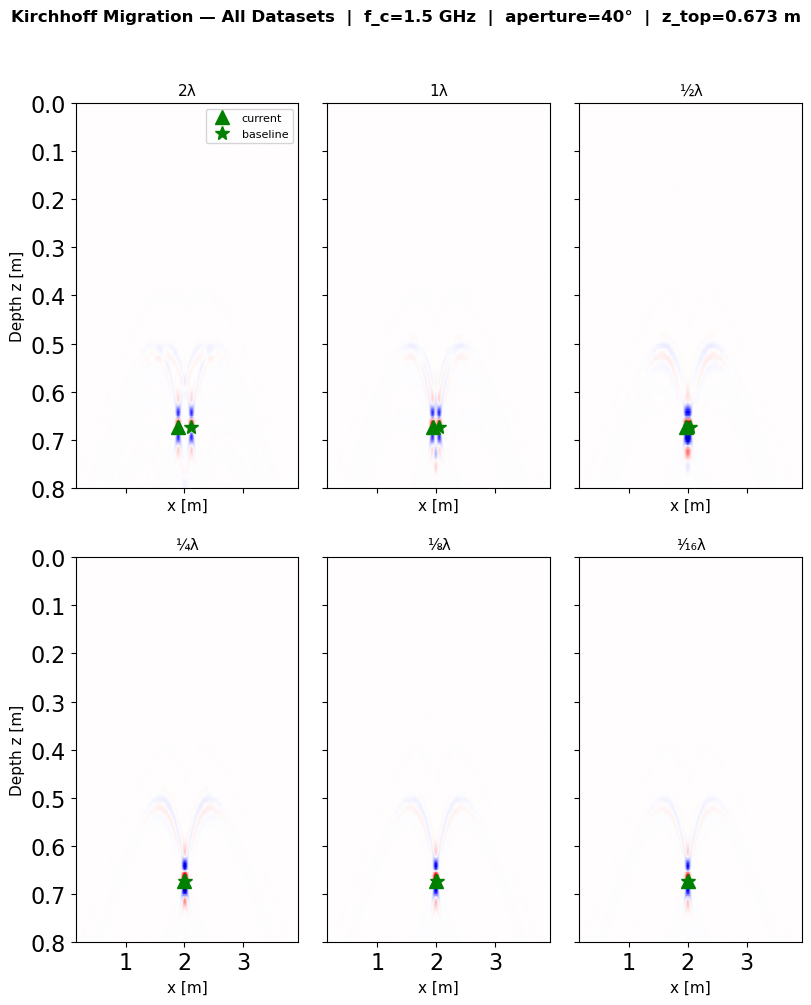

  [saved] Resolution_Study\Kirchhoff\RES_009_Kirchhoff_Migration_zoomed____f_c15_GHz____aperture40.png


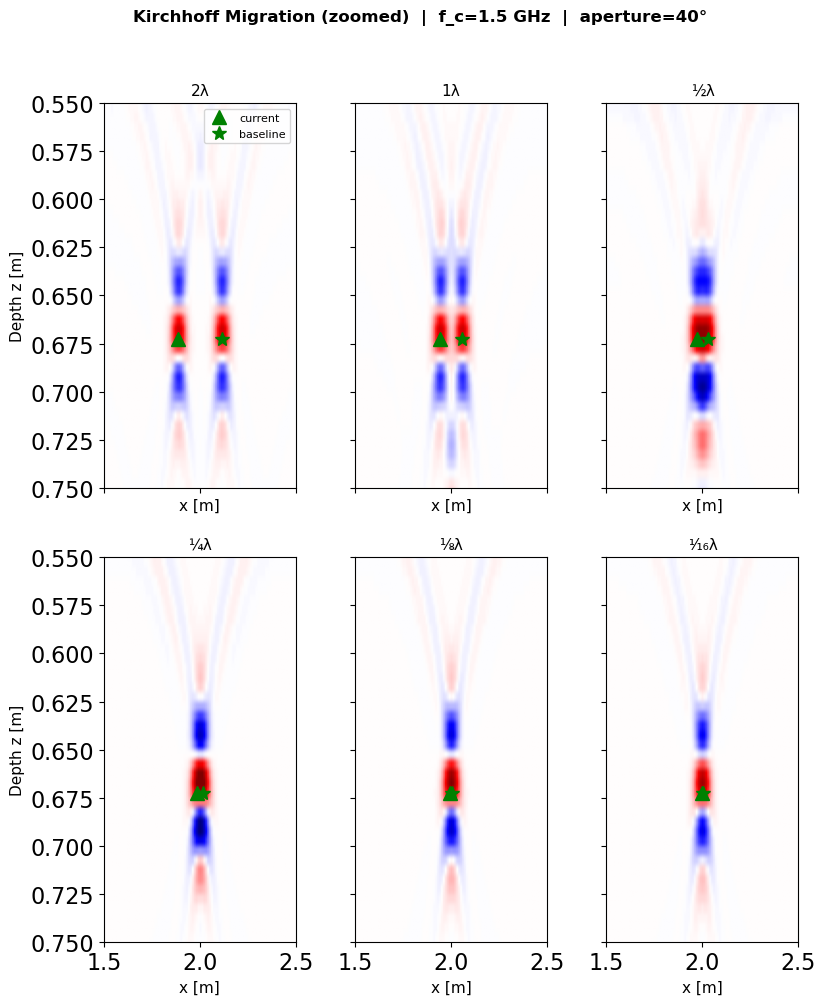

In [14]:
# ── Plot: full extent ──────────────────────────────────────────────────────────
extent_mig = [x_traces[0], x_traces[-1], z_img[-1], z_img[0]]

# Two static point scatterers per dataset (no baseline/current motion concept
# here): x1 mapped onto marker_x (triangle) and x2 onto marker_x_baseline
# (star) purely to reuse plot_migrated_grid's two-marker-per-panel support —
# see report for the marker-shape caveat.
marker_x1 = dict(zip(labels, x_s1_all))
marker_x2 = dict(zip(labels, x_s2_all))

fig, axes = plot_migrated_grid(
    migrated, extent_mig, ncols=3,
    marker_x=marker_x1, marker_z=z_top, marker_x_baseline=marker_x2,
    title=(f'Kirchhoff Migration — All Datasets  |  f_c={f_c_GHz} GHz  |  '
           f'aperture={ANGLE_AP}°  |  z_top={z_top:.3f} m'),
)
plt.show()

# ── Plot: zoomed on scatterer region ──────────────────────────────────────────
[(fig, axes)] = plot_migrated_grid(
    migrated, extent_mig, ncols=3,
    marker_x=marker_x1, marker_z=z_top, marker_x_baseline=marker_x2,
    title=f'Kirchhoff Migration (zoomed)  |  f_c={f_c_GHz} GHz  |  aperture={ANGLE_AP}°',
    zooms=[((1.5, 2.5), (0.75, 0.55), '')],
)
plt.show()


# Gazdag Phase-Shift Migration

f-k domain migration via **PyLops `PhaseShift`** downward continuation.  
Uses the same preprocessed (tapered + t0-shifted) B-scans as Kirchhoff, but operates in the
frequency-wavenumber domain: each depth step phase-shifts the wavefield by `kz·dz`.

Key implementation details:
- `v_mig = v_ice / 2` (exploding-reflector half-velocity) used internally
- 100 % spatial zero-padding each side to avoid wrap-around in kx
- Evanescent bins (`|kx| > |f|/v_mig`) are zeroed **before** the depth loop to prevent smile artefacts accumulating at the t = 0 imaging condition
- Green stars mark the true cylinder-top positions

_____________
Add padding in space and time up to the next power of 2
_____________

In [15]:
import pylops

## Run Migration on All Datasets

In [ ]:
# ── Gazdag phase-shift migration on all 6 datasets ────────────────────────────
migrated_gz = {}

for label, raw in zip(labels, outputs):
    _, shifted = preprocess(raw, dt_ns, t0_ns, time_ns)   # (n_tr, n_t), t0-shifted
    print(f'[{label}] Running Gazdag ...', flush=True)
    t0 = _time.perf_counter()
    img = gazdag_migration(
        shifted.T,       # (n_t, n_tr) — time first
        x_traces, time_ns, z_img, v_ice
    )
    print(f'  Done in {_time.perf_counter()-t0:.1f} s  shape={img.shape}')
    migrated_gz[label] = img

  [saved] Resolution_Study\Gazdag\RES_010_Gazdag_Phase-Shift_Migration__All_Datasets____f_c15_GHz____z.png


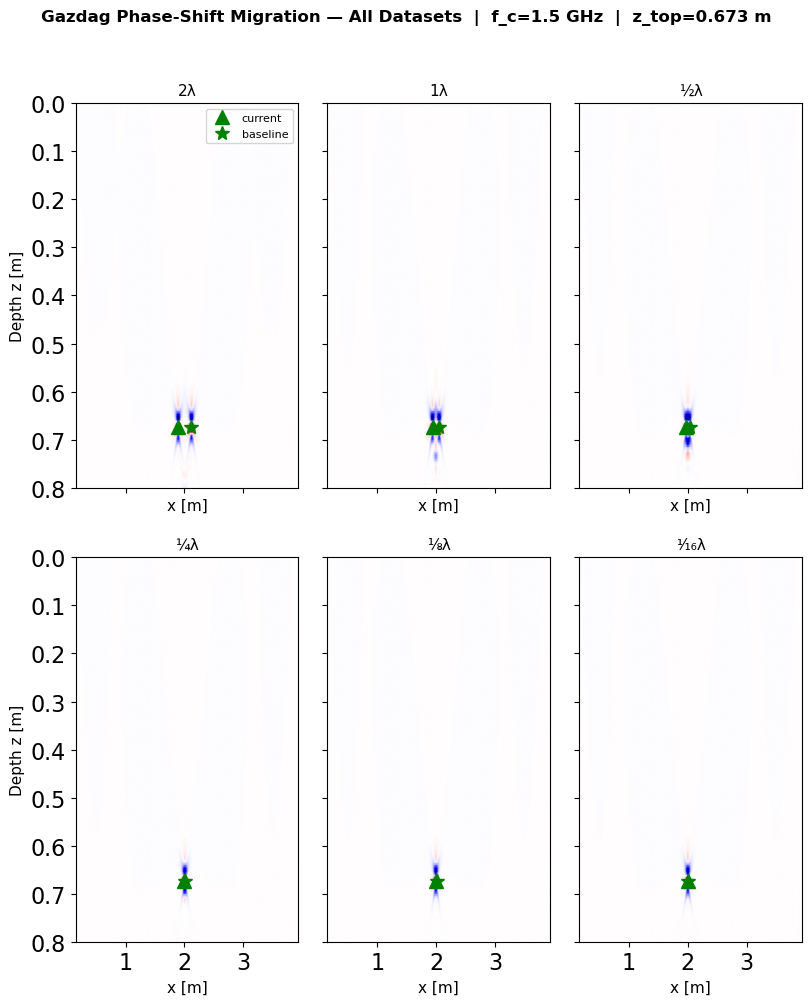

  [saved] Resolution_Study\Gazdag\RES_011_Gazdag_Phase-Shift_Migration_zoomed____f_c15_GHz.png


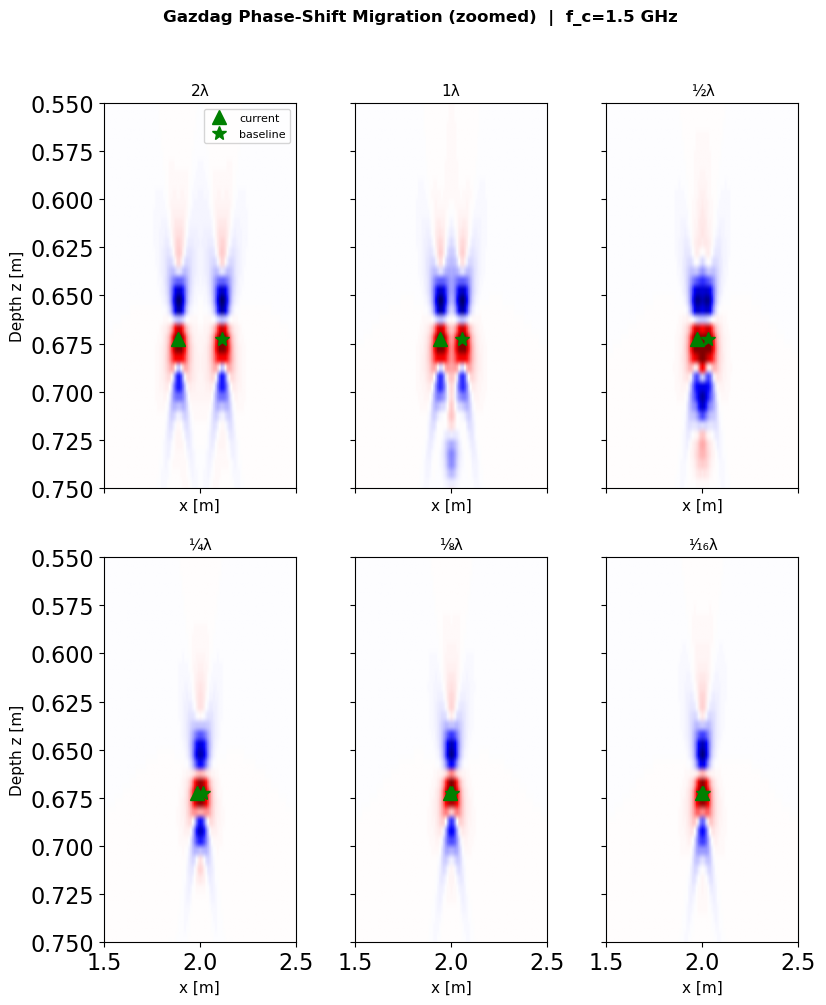

In [16]:
# ── Plot: full extent ──────────────────────────────────────────────────────────
marker_x1 = dict(zip(labels, x_s1_all))
marker_x2 = dict(zip(labels, x_s2_all))

fig, axes = plot_migrated_grid(
    migrated_gz, extent_mig, ncols=3,
    marker_x=marker_x1, marker_z=z_top, marker_x_baseline=marker_x2,
    title=(f'Gazdag Phase-Shift Migration — All Datasets  |  f_c={f_c_GHz} GHz  |  '
           f'z_top={z_top:.3f} m'),
)
plt.show()

# ── Plot: zoomed on scatterer region ──────────────────────────────────────────
[(fig, axes)] = plot_migrated_grid(
    migrated_gz, extent_mig, ncols=3,
    marker_x=marker_x1, marker_z=z_top, marker_x_baseline=marker_x2,
    title=f'Gazdag Phase-Shift Migration (zoomed)  |  f_c={f_c_GHz} GHz',
    zooms=[((1.5, 2.5), (0.75, 0.55), '')],
)
plt.show()


# Least-Squares Migration (LSM): Data Domain

Iterative inversion of the Kirchhoff operator **K**: find model **m** such that `Km ≈ d`.  
Applied only to the **2λ dataset** — each inversion is expensive due to the large operator size.

| Solver | Objective | Tuning parameter |
|--------|-----------|-----------------|
| Adjoint | `K^H d` (Kirchhoff migration, baseline) | — |
| LSQR (Tikhonov) | `min ‖Km−d‖² + λ²‖m‖²` | `damp` (λ) |
| FISTA (L1 sparse) | `min ‖Km−d‖² + ε‖m‖₁` | `eps_frac` (ε as % of adjoint peak) |

**Workflow:**  
1. Build the operator K and compute the adjoint image  
2. Sweep regularisation parameters via **L-curve** + **focusing score**  
3. Run the final solvers with the optimal parameters

In [17]:
from scipy.sparse.linalg import lsqr as sp_lsqr

# ── Preprocessed 2λ data ──────────────────────────────────────────────────────
_, shifted_2lam = preprocess(outputs[0], dt_ns, t0_ns, time_ns)   # (n_tr, n_t)

# ── Build Kirchhoff operator (once, reused for all solvers) ───────────────────
print('Building Kirchhoff operator for 2λ dataset ...')
t_op = _time.perf_counter()
m_adj, lsm_K = PylopsKirchoffMigration(
    shifted_2lam, time_ns, x_traces, v_ice, z_img,
    f0=f_c_GHz, angleaperture=ANGLE_AP, return_op=True
)
d_lsm        = shifted_2lam.flatten()
n_x_lsm      = len(x_traces)
n_z_lsm      = len(z_img)
adjoint_peak = np.max(np.abs(m_adj))

print(f'  K: {lsm_K.shape}  built in {_time.perf_counter()-t_op:.1f} s')
print(f'  d: {d_lsm.shape},  adjoint peak = {adjoint_peak:.3e}')

# ── Lipschitz constant via power iteration (needed for FISTA step size) ───────
print('\nEstimating Lipschitz constant (20 power iterations) ...')
np.random.seed(42)
_x_pr = np.random.randn(n_x_lsm * n_z_lsm)
_x_pr /= np.linalg.norm(_x_pr)
for _ in range(20):
    _x_pr = lsm_K.H @ (lsm_K @ _x_pr)
    _lip  = np.linalg.norm(_x_pr)
    _x_pr /= (_lip + 1e-30)
alpha_fista = 1.0 / _lip
print(f'  ‖K‖² ≈ {_lip:.3e},  step α = {alpha_fista:.3e}')

Building Kirchhoff operator for 2λ dataset ...
d.shape: (3222780,) K dimension: (3222780, 60800)
  K: (3222780, 60800)  built in 2.5 s
  d: (3222780,),  adjoint peak = 2.998e+01

Estimating Lipschitz constant (20 power iterations) ...


KeyboardInterrupt: 

In [ ]:
# ── Focusing-score and L-curve helpers ────────────────────────────────────────
x1_true, x2_true = x_s1_all[0], x_s2_all[0]
ix1 = np.argmin(np.abs(x_traces - x1_true))
ix2 = np.argmin(np.abs(x_traces - x2_true))
iz  = np.argmin(np.abs(z_img    - z_top))
HW_X, HW_Z = 6, 4

print(f'Scatterer pixel positions:')
print(f'  s1: x={x_traces[ix1]:.4f} m (true {x1_true:.4f} m)  ix={ix1}')
print(f'  s2: x={x_traces[ix2]:.4f} m (true {x2_true:.4f} m)  ix={ix2}')
print(f'   z: z={z_img[iz]:.4f} m     (true {z_top:.4f} m)    iz={iz}')

def focusing_score(img):
    """Signal / background-RMS ratio using known scatterer positions."""
    def _win(ix_c):
        return img[max(0,iz-HW_Z):iz+HW_Z+1, max(0,ix_c-HW_X):ix_c+HW_X+1]
    signal = 0.5 * (np.max(np.abs(_win(ix1))) + np.max(np.abs(_win(ix2))))
    mask   = np.ones(img.shape, dtype=bool)
    for ix_c in (ix1, ix2):
        mask[max(0,iz-HW_Z):iz+HW_Z+1, max(0,ix_c-HW_X):ix_c+HW_X+1] = False
    return signal / (np.sqrt(np.mean(img[mask]**2)) + 1e-30)

def lcurve_corner(res_arr, norm_arr):
    """Index of maximum curvature in log-log space."""
    eta = np.log(np.maximum(norm_arr, 1e-30))
    rho = np.log(np.maximum(res_arr,  1e-30))
    de, dr   = np.gradient(eta), np.gradient(rho)
    d2e, d2r = np.gradient(de),  np.gradient(dr)
    return int(np.argmax(np.abs(dr*d2e - de*d2r) / (dr**2 + de**2)**1.5))

t_sw = _time.perf_counter()

# ── Analysis 1: CGLS semi-convergence (damp=0, sweep stopping iteration) ──────
# Root cause of the straight L-curve: 15 iterations is far too few for a
# 1.6M×60k problem — LSQR barely moves, so all damp values produce nearly
# identical (under-resolved) solutions.
#
# CGLS semi-convergence avoids this entirely: run with damp=0 and treat the
# stopping iteration as the single regularisation parameter. The Krylov
# subspace grows with each step, so early stopping keeps the solution smooth
# while later stopping allows more detail. No damping value to choose.

cgls_iters = [5, 10, 15, 20, 30, 40, 50]
r_cgls, mn_cgls, fs_cgls = [], [], []
print(f'\n── Analysis 1: CGLS semi-convergence  ({len(cgls_iters)} stopping points, damp=0) ──')
for n_it in cgls_iters:
    res   = sp_lsqr(lsm_K, d_lsm, iter_lim=n_it, damp=0.0, show=False)
    m_vec = res[0]
    img   = m_vec.reshape(n_x_lsm, n_z_lsm).T
    r_cgls.append(np.linalg.norm(d_lsm - lsm_K @ m_vec))
    mn_cgls.append(np.linalg.norm(m_vec))
    fs_cgls.append(focusing_score(img))
    print(f'  iter={n_it:3d}  r={r_cgls[-1]:.3e}  ‖m‖={mn_cgls[-1]:.3e}  focus={fs_cgls[-1]:.2f}')

r_cgls, mn_cgls, fs_cgls = map(np.array, (r_cgls, mn_cgls, fs_cgls))
cgls_if  = int(np.argmax(fs_cgls))
cgls_ic  = lcurve_corner(r_cgls, mn_cgls)
ITER_OPT = cgls_iters[cgls_if]
print(f'  → Optimal stopping: iter={ITER_OPT}  (focus={fs_cgls[cgls_if]:.2f})')

# ── Analysis 2: LSQR Tikhonov — increased iterations so curve can bend ────────
SWEEP_ITERS = 50   # was 15: needs to be high enough for residuals to diverge across damps
damp_range  = np.logspace(-3, 1, 12)
r_lsqr, mn_lsqr, fs_lsqr = [], [], []
print(f'\n── Analysis 2: LSQR Tikhonov  ({len(damp_range)} damp values, iter_lim={SWEEP_ITERS}) ──')
for damp in damp_range:
    res   = sp_lsqr(lsm_K, d_lsm, iter_lim=SWEEP_ITERS, damp=damp, show=False)
    m_vec = res[0]
    img   = m_vec.reshape(n_x_lsm, n_z_lsm).T
    r_lsqr.append(np.linalg.norm(d_lsm - lsm_K @ m_vec))
    mn_lsqr.append(np.linalg.norm(m_vec))
    fs_lsqr.append(focusing_score(img))
    print(f'  damp={damp:.2e}  r={r_lsqr[-1]:.3e}  focus={fs_lsqr[-1]:.2f}')

r_lsqr, mn_lsqr, fs_lsqr = map(np.array, (r_lsqr, mn_lsqr, fs_lsqr))
lsqr_ic  = lcurve_corner(r_lsqr, mn_lsqr)
lsqr_if  = int(np.argmax(fs_lsqr))
DAMP_OPT = damp_range[lsqr_if]

# ── Analysis 3: FISTA eps sweep — more iterations per point ───────────────────
FISTA_SWEEP = 40   # was 20
efrac_range = np.logspace(-2, np.log10(0.3), 12)
r_fista, mn_fista, fs_fista = [], [], []
print(f'\n── Analysis 3: FISTA  ({len(efrac_range)} eps_frac values, niter={FISTA_SWEEP}) ──')
for efrac in efrac_range:
    eps = efrac * adjoint_peak
    res = pylops.optimization.sparsity.fista(
        lsm_K, d_lsm, niter=FISTA_SWEEP, eps=eps, alpha=alpha_fista, show=False
    )
    m_vec = res[0]
    img   = m_vec.reshape(n_x_lsm, n_z_lsm).T
    r_fista.append(np.linalg.norm(d_lsm - lsm_K @ m_vec))
    mn_fista.append(np.linalg.norm(m_vec, ord=1))
    fs_fista.append(focusing_score(img))
    print(f'  eps_frac={efrac:.3f}  r={r_fista[-1]:.3e}  focus={fs_fista[-1]:.2f}')

r_fista, mn_fista, fs_fista = map(np.array, (r_fista, mn_fista, fs_fista))
fista_ic     = lcurve_corner(r_fista, mn_fista)
fista_if     = int(np.argmax(fs_fista))
EPS_FRAC_OPT = efrac_range[fista_if]

print(f'\nTotal sweep time: {_time.perf_counter()-t_sw:.0f} s')
print(f'Optimal parameters:')
print(f'  CGLS : ITER_OPT     = {ITER_OPT}          (focus={fs_cgls[cgls_if]:.2f})')
print(f'  LSQR : DAMP_OPT     = {DAMP_OPT:.2e}  (focus={fs_lsqr[lsqr_if]:.2f})')
print(f'  FISTA: EPS_FRAC_OPT = {EPS_FRAC_OPT:.3f}     (focus={fs_fista[fista_if]:.2f})')

# ── 2×3 figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Row 0: L-curves
ax = axes[0, 0]
ax.loglog(mn_cgls, r_cgls, 'b.-', ms=7)
ax.plot(mn_cgls[cgls_ic], r_cgls[cgls_ic], 'r*', ms=14, zorder=5,
        label=f'L-curve corner  iter={cgls_iters[cgls_ic]}')
ax.plot(mn_cgls[cgls_if], r_cgls[cgls_if], 'g^', ms=10, zorder=5,
        label=f'Best focus      iter={ITER_OPT}')
for i, n in enumerate(cgls_iters):
    ax.annotate(str(n), (mn_cgls[i], r_cgls[i]),
                fontsize=7, xytext=(4, 3), textcoords='offset points')
ax.set(xlabel='‖m‖₂', ylabel='‖Km−d‖₂',
       title='CGLS — L-curve  (iteration = regulariser)')
ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)

ax = axes[0, 1]
ax.loglog(r_lsqr, mn_lsqr, 'b.-', ms=7)
ax.plot(r_lsqr[lsqr_ic], mn_lsqr[lsqr_ic], 'r*', ms=14, zorder=5,
        label=f'L-curve corner  λ={damp_range[lsqr_ic]:.1e}')
ax.plot(r_lsqr[lsqr_if], mn_lsqr[lsqr_if], 'g^', ms=10, zorder=5,
        label=f'Best focus      λ={damp_range[lsqr_if]:.1e}')
for i in range(len(damp_range)):
    ax.annotate(f'{damp_range[i]:.0e}', (r_lsqr[i], mn_lsqr[i]),
                fontsize=7, xytext=(4, 3), textcoords='offset points')
ax.set(xlabel='‖Km−d‖₂', ylabel='‖m‖₂',
       title=f'LSQR Tikhonov — L-curve  (iter_lim={SWEEP_ITERS})')
ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)

ax = axes[0, 2]
ax.loglog(r_fista, mn_fista, 'b.-', ms=7)
ax.plot(r_fista[fista_ic], mn_fista[fista_ic], 'r*', ms=14, zorder=5,
        label=f'L-curve corner  ε={efrac_range[fista_ic]:.2f}')
ax.plot(r_fista[fista_if], mn_fista[fista_if], 'g^', ms=10, zorder=5,
        label=f'Best focus      ε={efrac_range[fista_if]:.2f}')
for i in range(len(efrac_range)):
    ax.annotate(f'{efrac_range[i]:.2f}', (r_fista[i], mn_fista[i]),
                fontsize=7, xytext=(4, 3), textcoords='offset points')
ax.set(xlabel='‖Km−d‖₂', ylabel='‖m‖₁',
       title=f'FISTA — L-curve  (niter={FISTA_SWEEP})')
ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)

# Row 1: focusing scores
ax = axes[1, 0]
ax.plot(cgls_iters, fs_cgls, 'b.-', ms=7)
ax.axvline(cgls_iters[cgls_ic], color='r', ls='--', lw=1.5,
           label=f'L-curve corner  (iter={cgls_iters[cgls_ic]})')
ax.axvline(ITER_OPT,            color='g', ls='--', lw=1.5,
           label=f'Best focus      (iter={ITER_OPT})')
ax.set(xlabel='CGLS stopping iteration', ylabel='Focusing score  (signal / bg-RMS)',
       title='CGLS — focusing score')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.semilogx(damp_range, fs_lsqr, 'b.-', ms=7)
ax.axvline(damp_range[lsqr_ic], color='r', ls='--', lw=1.5,
           label=f'L-curve corner  ({damp_range[lsqr_ic]:.1e})')
ax.axvline(DAMP_OPT,            color='g', ls='--', lw=1.5,
           label=f'Best focus      ({DAMP_OPT:.1e})')
ax.set(xlabel='Damping  λ', ylabel='Focusing score  (signal / bg-RMS)',
       title=f'LSQR Tikhonov — focusing score (iter={SWEEP_ITERS})')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 2]
ax.semilogx(efrac_range, fs_fista, 'b.-', ms=7)
ax.axvline(efrac_range[fista_ic], color='r', ls='--', lw=1.5,
           label=f'L-curve corner  ({efrac_range[fista_ic]:.2f})')
ax.axvline(EPS_FRAC_OPT,          color='g', ls='--', lw=1.5,
           label=f'Best focus      ({EPS_FRAC_OPT:.2f})')
ax.set(xlabel='eps_frac', ylabel='Focusing score  (signal / bg-RMS)',
       title=f'FISTA — focusing score (niter={FISTA_SWEEP})')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle(
    f'LSM Parameter Selection — 2λ dataset  |  f_c={f_c_GHz} GHz\n'
    f'★ L-curve corner (no ground truth)   ▲ Best focusing score (uses true scatterer positions)',
    fontsize=10, y=1.01
)
plt.tight_layout()
plt.show()


## Final LSM — Adjoint · CGLS · LSQR · FISTA

Run all four solvers with parameters chosen by the analysis above.

In [ ]:
DAMP_OPT = 5
EPS_FRAC_OPT = 0.6
ITER_OPT = 15

In [ ]:
LSQR_FINAL_ITERS  = 30
FISTA_FINAL_ITERS = 50

# # ── CGLS: optimal early stopping (damp=0) ─────────────────────────────────────
# print(f'CGLS  iter_lim={ITER_OPT}  damp=0 ...')
t0 = _time.perf_counter()
res_cgls = sp_lsqr(lsm_K, d_lsm, iter_lim=ITER_OPT, damp=0.0, show=False)
m_cgls   = res_cgls[0].reshape(n_x_lsm, n_z_lsm).T
print(f'  Done in {_time.perf_counter()-t0:.1f} s')

# ── LSQR with optimal Tikhonov damping ────────────────────────────────────────
print(f'\nLSQR  λ={DAMP_OPT:.2e}  iter_lim={LSQR_FINAL_ITERS} ...')
t0 = _time.perf_counter()
res_lsqr = sp_lsqr(lsm_K, d_lsm, iter_lim=LSQR_FINAL_ITERS, damp=DAMP_OPT, show=False)
m_lsqr   = res_lsqr[0].reshape(n_x_lsm, n_z_lsm).T
print(f'  Done in {_time.perf_counter()-t0:.1f} s  itn={res_lsqr[2]}')

# ── FISTA with optimal eps ─────────────────────────────────────────────────────
eps_opt = EPS_FRAC_OPT * adjoint_peak
print(f'\nFISTA  ε={eps_opt:.3e} ({EPS_FRAC_OPT*100:.1f}% adj. peak)  niter={FISTA_FINAL_ITERS} ...')
t0 = _time.perf_counter()
res_fista = pylops.optimization.sparsity.fista(
    lsm_K, d_lsm, niter=FISTA_FINAL_ITERS, eps=eps_opt, alpha=alpha_fista, show=False
)
m_fista = res_fista[0].reshape(n_x_lsm, n_z_lsm).T
print(f'  Done in {_time.perf_counter()-t0:.1f} s')

# ── Summary ────────────────────────────────────────────────────────────────────
print(f'\n{"Solver":<12}  {"‖Km−d‖":>12}  {"Focus":>8}')
for name, m_v in [('Adjoint', m_adj), ('CGLS', m_cgls), ('LSQR', m_lsqr), ('FISTA', m_fista)]:
    r = np.linalg.norm(d_lsm - lsm_K @ m_v.T.ravel())
    s = focusing_score(m_v)
    print(f'{name:<12}  {r:12.3e}  {s:8.2f}')

In [ ]:
x1_2lam, x2_2lam = x_s1_all[0], x_s2_all[0]

panels = [
    ('Adjoint\n(Kirchhoff migration)', m_adj),
    (f'CGLS  (early stopping)\niter={ITER_OPT},  damp=0', m_cgls),
    (f'LSQR  Tikhonov\nλ={DAMP_OPT:.1e},  iter={LSQR_FINAL_ITERS}', m_lsqr),
    (f'FISTA  L1\nε={EPS_FRAC_OPT*100:.1f}%,  niter={FISTA_FINAL_ITERS}', m_fista),
]

# ── Plot: full extent ──────────────────────────────────────────────────────────
fig, axes = plot_migrated_grid(
    panels, extent_mig, ncols=4,
    marker_x=x1_2lam, marker_z=z_top, marker_x_baseline=x2_2lam,
    title=f'Least-Squares Migration — 2λ dataset  |  f_c={f_c_GHz} GHz  |  aperture={ANGLE_AP}°',
    figsize=(20, 5),
)
plt.show()

# ── Plot: zoomed on scatterer region ──────────────────────────────────────────
[(fig, axes)] = plot_migrated_grid(
    panels, extent_mig, ncols=4,
    marker_x=x1_2lam, marker_z=z_top, marker_x_baseline=x2_2lam,
    title=f'Least-Squares Migration — 2λ dataset (zoomed)  |  f_c={f_c_GHz} GHz  |  aperture={ANGLE_AP}°',
    zooms=[((1.5, 2.5), (0.75, 0.55), '')],
    figsize=(20, 5),
)
plt.show()


# Image Domain Least-Squares Migration (ILSM)

Instead of repeatedly applying the full forward/adjoint Kirchhoff operator, ILSM
approximates the **Hessian** H = K^H K directly in the image domain:

> **m** = H **r**  →  H ≈ NonStationaryConvolve2D

**Steps:**
1. Place a grid of point scatterers (PSF reflectivity)
2. Forward-model + migrate: `d_psf = K @ psf_refl`, `m_psf = K.H @ d_psf` (2 matvecs total)
3. Extract local PSF patches from `m_psf` — each patch is the spatially-varying impulse response
4. Build `Cop` (PyLops `NonStationaryConvolve2D`) as the Hessian approximation
5. Invert `Cop @ r = m_adj` with FISTA — **no further K applications**


In [ ]:
# ── PSF grid parameters ──────────────────────────────────────────────────────
n_x_img, n_z_img = len(x_traces), len(z_img)   # 380, 160
PSFSIZE   = (31, 21)   # patch half-size (x, z) pixels — must fit inside image
PSFJ      = (30, 20)   # PSF grid spacing (x, z) pixels
PSFMARGIN = (PSFSIZE[0]//2 + 1, PSFSIZE[1]//2 + 1)   # boundary clearance

psfx_idx = np.arange(PSFMARGIN[0], n_x_img - PSFMARGIN[0], PSFJ[0])
psfz_idx = np.arange(PSFMARGIN[1], n_z_img - PSFMARGIN[1], PSFJ[1])
print(f'PSF grid: {len(psfx_idx)} x {len(psfz_idx)} = {len(psfx_idx)*len(psfz_idx)} points'
      f'  patch size: {PSFSIZE[0]}x{PSFSIZE[1]}')

# PSF reflectivity in K's (nx, nz) model convention
psf_refl_nxnz = np.zeros((n_x_img, n_z_img))
for _ix in psfx_idx:
    for _iz in psfz_idx:
        psf_refl_nxnz[_ix, _iz] = 1.0

# ── Forward model + migrate (2 K-applications total) ─────────────────────────
print('Forward modelling PSF reflectivity ...')
t0 = _time.perf_counter()
d_psf      = lsm_K @ psf_refl_nxnz.ravel()                        # (n_tr x n_t)
print(f'  Forward done in {_time.perf_counter()-t0:.1f} s')
t0 = _time.perf_counter()
m_psf_nxnz = (lsm_K.H @ d_psf).reshape(n_x_img, n_z_img)          # (nx, nz)
print(f'  Migration done in {_time.perf_counter()-t0:.1f} s')

# ── Extract PSF patches ───────────────────────────────────────────────────────
psfs = np.zeros((len(psfx_idx), len(psfz_idx), *PSFSIZE))
hw_x, hw_z = PSFSIZE[0]//2, PSFSIZE[1]//2
for ipx, px in enumerate(psfx_idx):
    for ipz, pz in enumerate(psfz_idx):
        psfs[ipx, ipz] = m_psf_nxnz[
            px - hw_x : px + hw_x + 1,
            pz - hw_z : pz + hw_z + 1,
        ]
print(f'PSF patches extracted  shape: {psfs.shape}')

# ── Plot: PSF reflectivity and migrated PSF image ─────────────────────────────
extent_mig = [x_traces[0], x_traces[-1], z_img[-1], z_img[0]]
fig, axes  = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(psf_refl_nxnz.T, aspect='auto', cmap='gray_r',
               extent=extent_mig, origin='upper')
axes[0].set(title='PSF reflectivity (point scatterer grid)',
            xlabel='x [m]', ylabel='Depth z [m]')

vmax_psf = np.percentile(np.abs(m_psf_nxnz), 99)
axes[1].imshow(m_psf_nxnz.T, aspect='auto', cmap='seismic',
               vmin=-vmax_psf, vmax=vmax_psf, extent=extent_mig, origin='upper')
axes[1].set(title='Migrated PSFs  (spatially-varying Hessian impulse responses)',
            xlabel='x [m]', ylabel='Depth z [m]')

plt.suptitle('ILSM — PSF computation  |  2λ dataset', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# ── Build NonStationaryConvolve2D Hessian approximation ──────────────────────
Cop = pylops.signalprocessing.NonStationaryConvolve2D(
    hs=psfs, ihx=psfx_idx, ihz=psfz_idx,
    dims=(n_x_img, n_z_img), engine='numba'
)
print(f'Cop shape: {Cop.shape}')

# ── FISTA inversion: solve Cop @ r = m_adj ────────────────────────────────────
# m_adj is (nz, nx); K's model convention is (nx, nz) → transpose before passing
m_adj_nxnz = m_adj.T   # (nx, nz)
EPS_ILSM   = 1e3        # regularisation strength — increase for sparser result

print(f'Running FISTA (eps={EPS_ILSM:.0e}, niter=100) ...')
t0 = _time.perf_counter()
m_ilsm_vec, _, _ = pylops.optimization.sparsity.fista(
    Cop, m_adj_nxnz.ravel(), eps=EPS_ILSM, niter=100,
    eigsdict=dict(niter=5, tol=1e-2), show=False
)
m_ilsm = m_ilsm_vec.reshape(n_x_img, n_z_img).T   # back to (nz, nx)
print(f'Done in {_time.perf_counter()-t0:.1f} s')

# ── Plot: adjoint vs ILSM ─────────────────────────────────────────────────────
x1_2lam, x2_2lam = x_s1_all[0], x_s2_all[0]
panels = [
    ('Adjoint  (Kirchhoff migration)', m_adj),
    (f'ILSM  eps={EPS_ILSM:.0e},  niter=100', m_ilsm),
]

# ── Plot: full extent ──────────────────────────────────────────────────────────
fig, axes = plot_migrated_grid(
    panels, extent_mig, ncols=2,
    marker_x=x1_2lam, marker_z=z_top, marker_x_baseline=x2_2lam,
    title=f'ILSM — 2λ dataset  |  f_c={f_c_GHz} GHz  |  aperture={ANGLE_AP}°',
    figsize=(13, 5),
)
plt.show()

# ── Plot: zoomed on scatterer region ──────────────────────────────────────────
[(fig, axes)] = plot_migrated_grid(
    panels, extent_mig, ncols=2,
    marker_x=x1_2lam, marker_z=z_top, marker_x_baseline=x2_2lam,
    title=f'ILSM — 2λ dataset (zoomed)  |  f_c={f_c_GHz} GHz  |  aperture={ANGLE_AP}°',
    zooms=[((1.5, 2.5), (0.75, 0.55), '')],
    figsize=(13, 5),
)
plt.show()


# Back-Propagation Migration

Time-reversal migration: re-inject the time-reversed, normalised B-scan traces at the
original receiver positions through a **half-velocity medium** (eps_r × 4 so v → v_ice/2).

Under the exploding-reflector hypothesis every scatterer focuses simultaneously at

> **t_focus = T − t0_ns**

where T is the total simulation window. Snapshots are captured in a narrow window just
before t_focus so the collapsed wavefield image can be extracted.

| Parameter | Value |
|-----------|-------|
| Injection positions | Rx locations (Tx + 0.1 m offset) |
| Medium | eps_r × 4 → v = v_ice / 2 |
| Source stride | every `STRIDE`-th trace (tunes performance vs coverage) |

In [18]:
# ── Back-propagation parameters ──────────────────────────────────────────────
# Sources placed at Tx-Rx midpoints (x_traces) — consistent with exploding-
# reflector half-velocity (v_mig = v/2) used in gazdag_migration.
slugs    = ['2lambda', '1lambda', '0p5lambda', '0p25lambda', '0p125lambda', '0p0625lambda']
STRIDE   = 1    # use every Nth trace — reduces gprMax source count
N_SNAP   = 30   # number of snapshots in the focus window
SNAP_WIN = 1.0  # [ns] window before focus time to capture

# ── Generate files for all 6 datasets ────────────────────────────────────────
print(f'Back-propagation file generation  (stride={STRIDE}, {N_SNAP} snapshots)\n')
bp_paths = {}
for label, slug, raw in zip(labels, slugs, outputs):
    tapered, _ = preprocess(raw, dt_ns, t0_ns, time_ns)
    in_path, n_src, n_snaps, t_focus = write_backprop_files(
        STUDY_ROOT, label, slug, tapered, dt_ns, x_traces,
        t0_ns, eps_r, v_ice, stride=STRIDE, n_snap=N_SNAP, snap_win=SNAP_WIN
    )
    bp_paths[label] = in_path
    exc_mb = (in_path.parent / 'excitation.txt').stat().st_size / 1e6
    print(f'  [{label}]  {n_src} sources  |  {n_snaps} snapshots  |  '
          f'focus={t_focus:.2f} ns  |  excitation={exc_mb:.1f} MB')
    print(f'           {in_path}')

Back-propagation file generation  (stride=1, 30 snapshots)

  [2λ]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=44.6 MB
           C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\resolution_study\backprop\2lambda\backprop_2lambda.in
  [1λ]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=44.8 MB
           C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\resolution_study\backprop\1lambda\backprop_1lambda.in
  [½λ]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=44.9 MB
           C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\resolution_study\backprop\0p5lambda\backprop_0p5lambda.in
  [¼λ]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=44.9 MB
           C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\resolution_study\backprop\0p25lambda\backprop_0p25lambda.in
  [⅛λ]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=44.9 MB
           C:\Users\Administrator\OneDr

[2λ]  29 snaps  |  focus idx=19  t=19.316 ns
[1λ]  29 snaps  |  focus idx=19  t=19.316 ns
[½λ]  29 snaps  |  focus idx=19  t=19.316 ns
[¼λ]  29 snaps  |  focus idx=19  t=19.316 ns
[⅛λ]  29 snaps  |  focus idx=19  t=19.316 ns
[¹⁄₁₆λ]  29 snaps  |  focus idx=19  t=19.316 ns
  [saved] Resolution_Study\Back-Propagation\RES_012_Back-Propagation_E__All_Datasets____focus_at_1906_ns.png


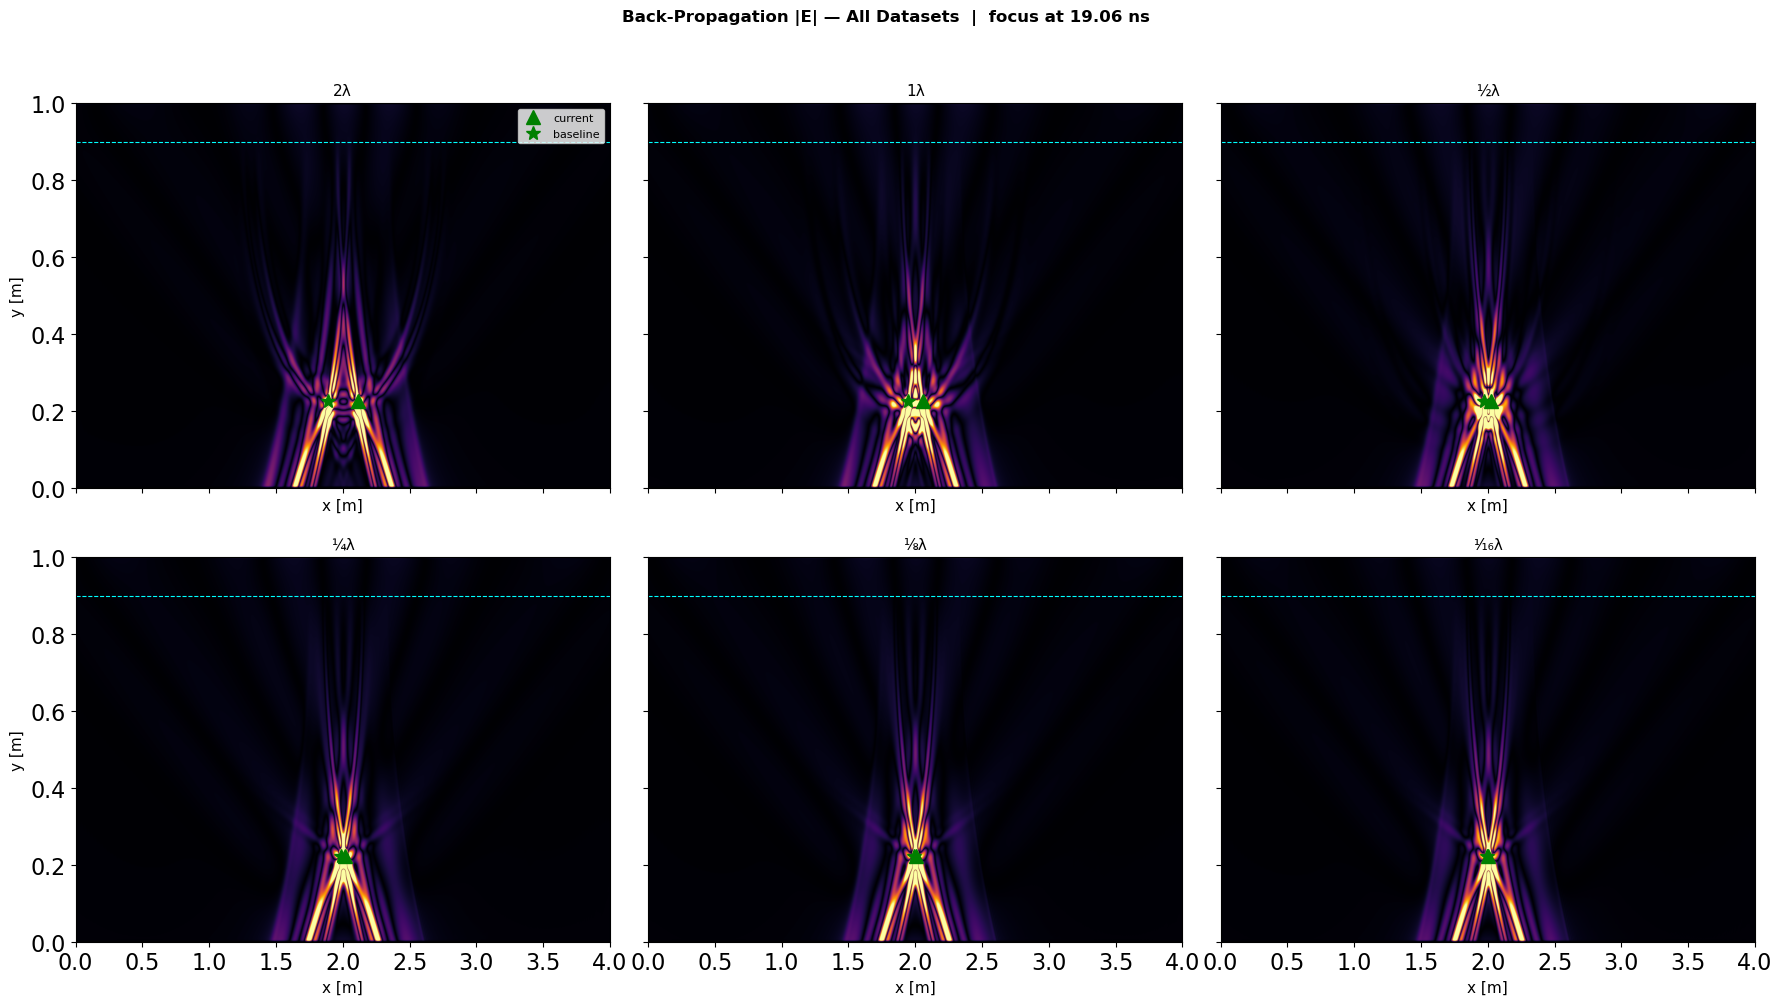

  [saved] Resolution_Study\Back-Propagation\RES_013_Back-Propagation_E_zoomed____focus_at_1906_ns.png


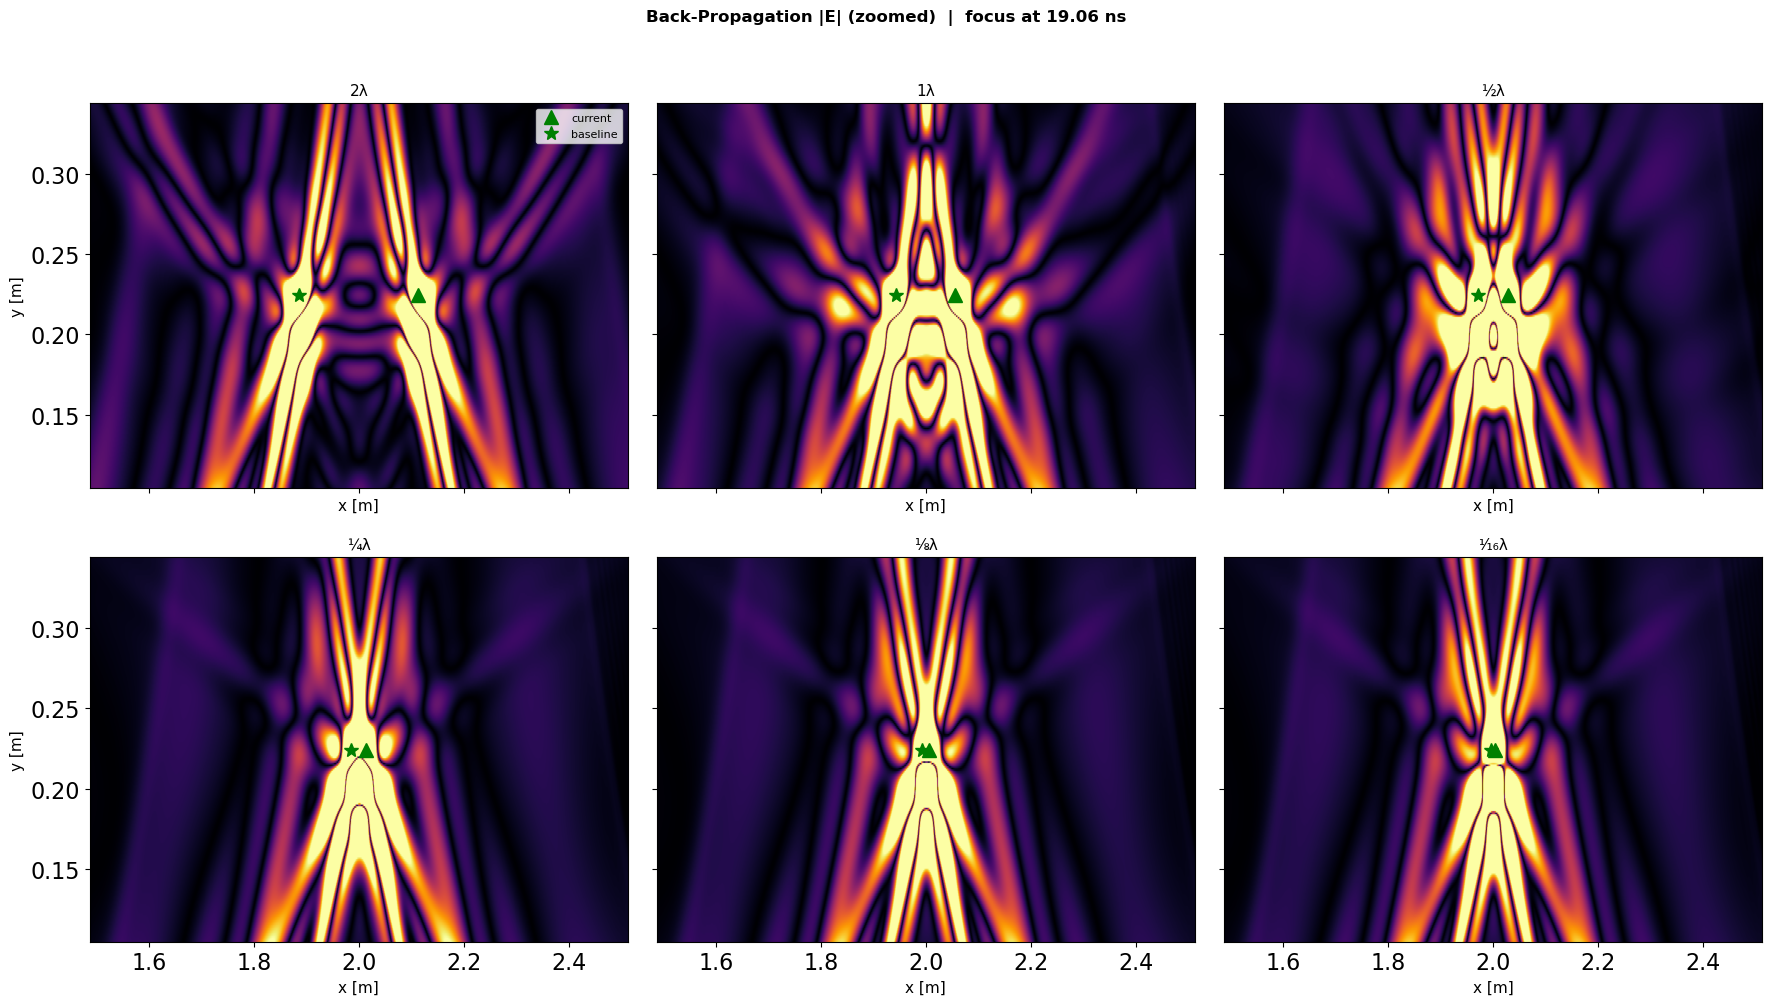

  [saved] Resolution_Study\Back-Propagation\RES_014_Back-Propagation_Ez__All_Datasets____focus_at_1906_ns.png


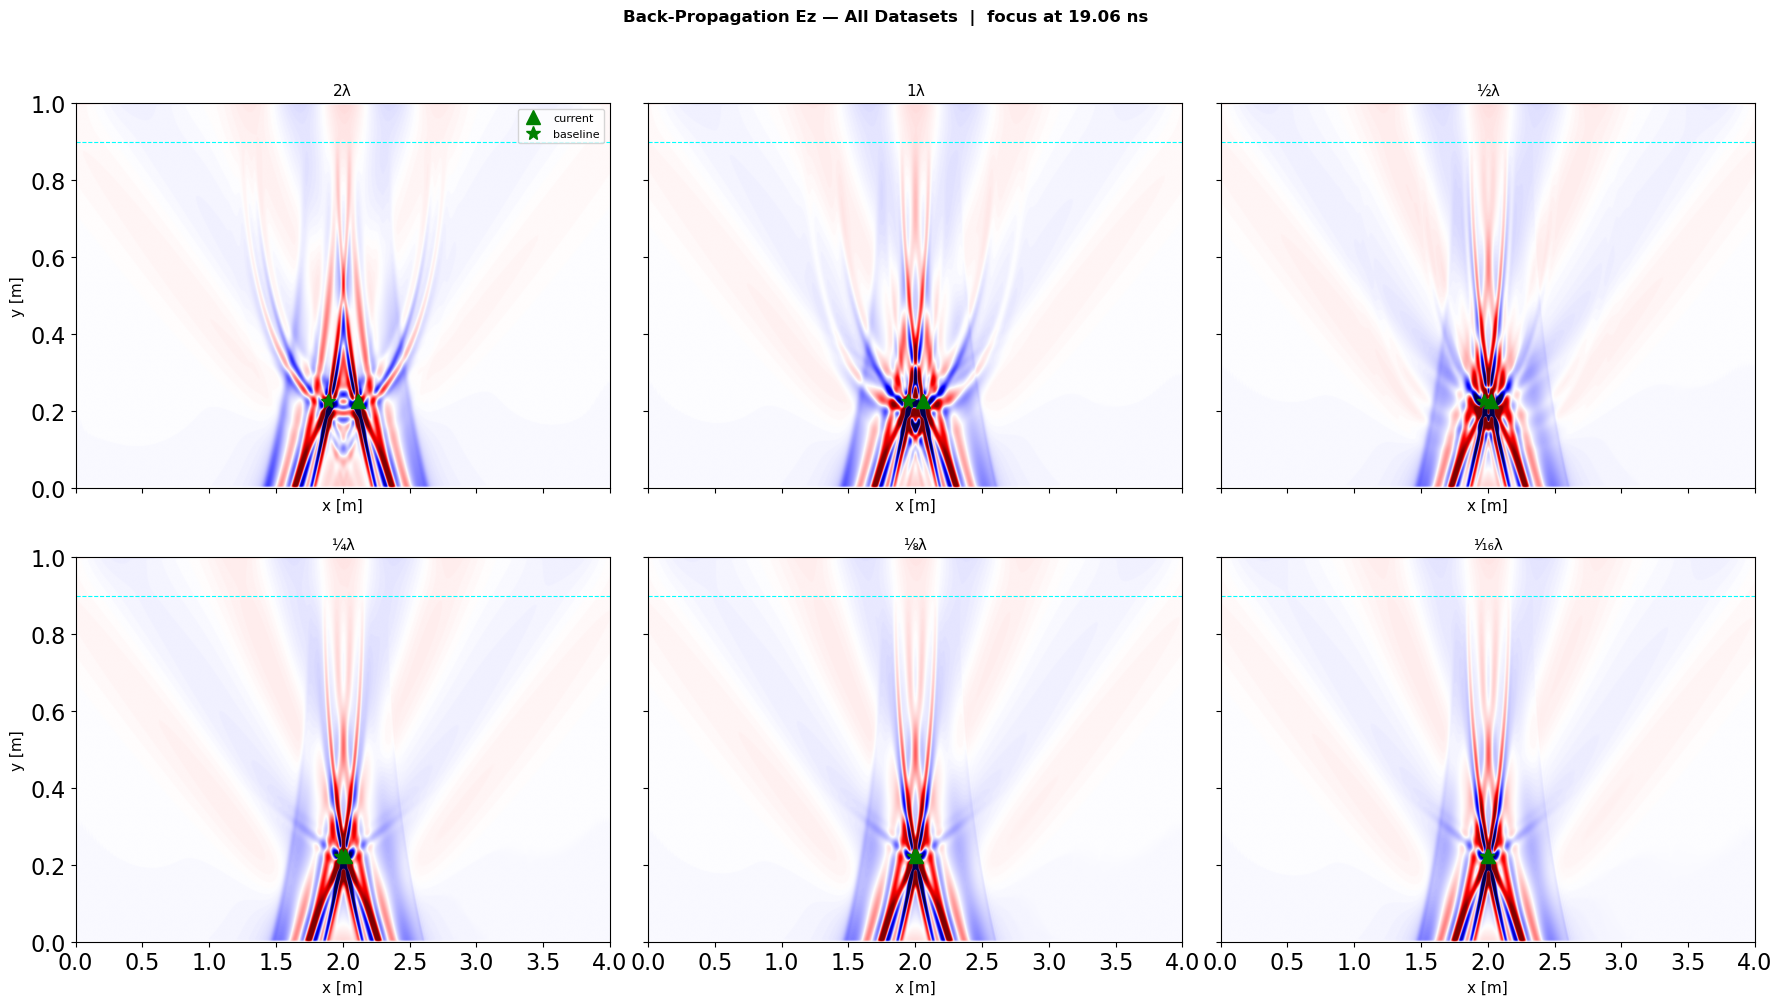

  [saved] Resolution_Study\Back-Propagation\RES_015_Back-Propagation_Ez_zoomed____focus_at_1906_ns.png


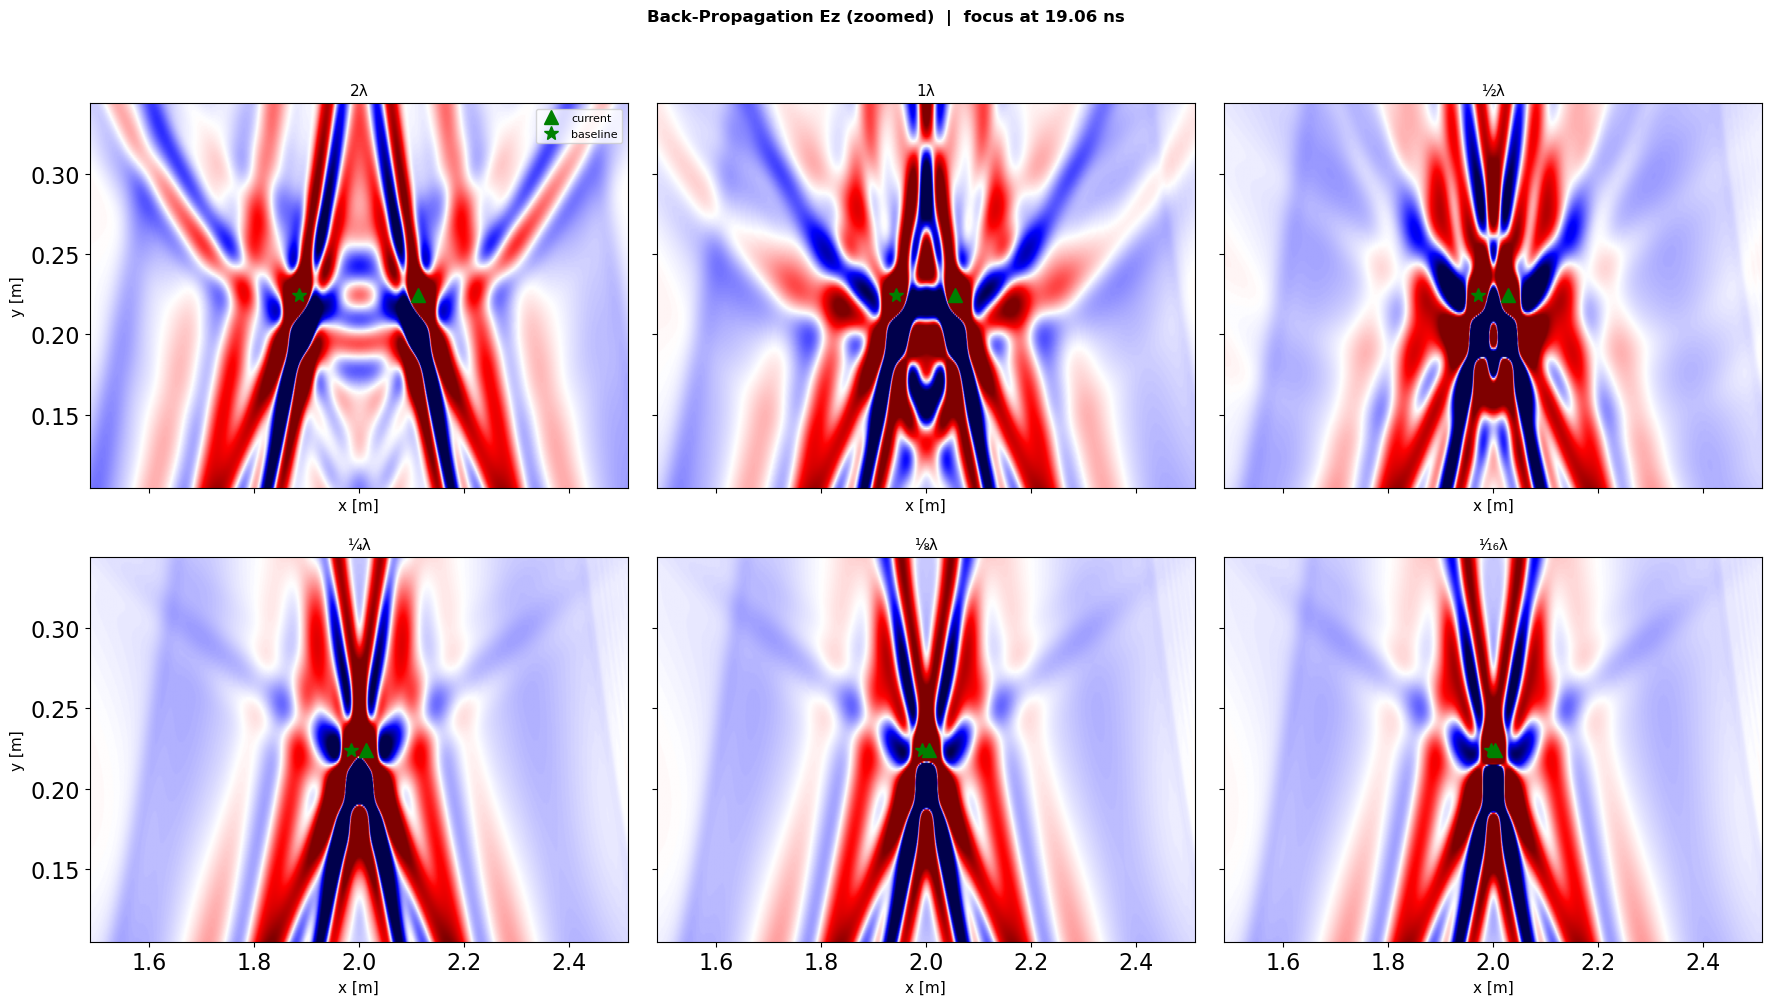

In [19]:
import pyvista

# ── Load focus frame for all 6 datasets ────────────────────────────────────────
T_ns_bp    = n_t * dt_ns
t_focus_ns = T_ns_bp - t0_ns
t_start_ns = max(0.0, t_focus_ns - SNAP_WIN)
dt_s       = dt_ns * 1e-9
snap_step_ref = max(1, int((T_ns_bp*1e-9 - t_start_ns*1e-9) / (max(1, N_SNAP - 1) * dt_s)))

focus_frames = {}
for i, (label, slug) in enumerate(zip(labels, slugs)):
    snap_dir   = STUDY_ROOT / 'backprop' / slug / f'backprop_{slug}_snaps'
    snap_files = sorted(
        snap_dir.glob('bp_snap*.vti'),
        key=lambda p: int(p.stem.replace('bp_snap', ''))
    )
    if not snap_files:
        print(f'[{label}] No snapshots in {snap_dir.name} — skipping')
        continue

    snap_times_ns = t_start_ns + np.arange(len(snap_files)) * snap_step_ref * dt_ns
    idx_focus     = min(int(np.argmin(np.abs(snap_times_ns - t_focus_ns))) + 4,
                        len(snap_files) - 1)

    # Derive grid dimensions from the first snapshot (avoids hardcoding)
    Nx_bp = Ny_bp = None
    snaps_mag, snaps_ez = [], []
    for p in snap_files:
        mesh   = pyvista.read(str(p))
        e_data = np.array(mesh['E-field'])
        if Nx_bp is None:
            Nx_bp = mesh.dimensions[0] - 1   # cells in x (= domain_x / dx = 4000)
            Ny_bp = mesh.dimensions[1] - 1   # cells in y (= domain_y / dy = 1000)
        snaps_mag.append(np.linalg.norm(e_data, axis=1).reshape(Ny_bp, Nx_bp))
        snaps_ez.append(e_data[:, 2].reshape(Ny_bp, Nx_bp))

    focus_frames[label] = {
        'mag':      np.stack(snaps_mag)[idx_focus],
        'ez':       np.stack(snaps_ez)[idx_focus],
        't_actual': snap_times_ns[idx_focus],
        'i':        i,
    }
    print(f'[{label}]  {len(snap_files)} snaps  |  focus idx={idx_focus}'
          f'  t={focus_frames[label]["t_actual"]:.3f} ns')

extent_full = [0, 4.0, 0, 1]
margin_x    = 0.4
margin_y    = 0.12

# Zoom x-window fixed to cover the widest (2λ) shift in all shared-axis panels
x_zoom_lo = x_scatterer_1[0] - margin_x
x_zoom_hi = x_scatterer_2[0] + margin_x   # right scatterer of 2λ (widest) separation

# ── Marker positions: two static scatterers per dataset ──────────────────────
# x_s1 (left) -> marker_x_baseline (star), x_s2 (right) -> marker_x (triangle),
# matching the original 'g*'/'g^' marker styling exactly.
frames_mag  = {label: frame['mag'] for label, frame in focus_frames.items()}
frames_ez   = {label: frame['ez']  for label, frame in focus_frames.items()}
marker_x_s1 = dict(zip(labels, x_scatterer_1))
marker_x_s2 = dict(zip(labels, x_scatterer_2))

# ── |E| magnitude — full extent 2×3 grid ──────────────────────────────────────
# NOTE: vmax_percentile=99.5 / vmax_headroom=1.0 fixes a dead-code bug in the
# original cell, where `vmax = np.percentile(frame['mag'], 99.5)` was computed
# but never passed into ax.imshow(...), so every panel was auto-scaled instead.
fig, axes = plot_wavefield_grid(
    frames_mag, extent_full, field='magnitude', ncols=3, y_surface=y_surface,
    marker_x=marker_x_s2, marker_y=y_scatterer, marker_x_baseline=marker_x_s1,
    vmax_percentile=99.5, vmax_headroom=1.0,
    title=f'Back-Propagation |E| — All Datasets  |  focus at {t_focus_ns:.2f} ns',
    figsize=(18, 10),
)
plt.show()

# ── |E| magnitude — zoomed 2×3 grid ──────────────────────────────────────────
[(fig, axes)] = plot_wavefield_grid(
    frames_mag, extent_full, field='magnitude', ncols=3,
    marker_x=marker_x_s2, marker_y=y_scatterer, marker_x_baseline=marker_x_s1,
    vmax_percentile=99.5, vmax_headroom=1.0,
    title=f'Back-Propagation |E| (zoomed)  |  focus at {t_focus_ns:.2f} ns',
    zooms=[((x_zoom_lo, x_zoom_hi), (y_scatterer - margin_y, y_scatterer + margin_y), '')],
    figsize=(18, 10),
)
plt.show()

# ── Ez component — full extent 2×3 grid ──────────────────────────────────────
fig, axes = plot_wavefield_grid(
    frames_ez, extent_full, field='signed', ncols=3, y_surface=y_surface,
    marker_x=marker_x_s2, marker_y=y_scatterer, marker_x_baseline=marker_x_s1,
    vmax_percentile=99.5, vmax_headroom=1.0,
    title=f'Back-Propagation Ez — All Datasets  |  focus at {t_focus_ns:.2f} ns',
    figsize=(18, 10),
)
plt.show()

# ── Ez component — zoomed 2×3 grid ───────────────────────────────────────────
[(fig, axes)] = plot_wavefield_grid(
    frames_ez, extent_full, field='signed', ncols=3,
    marker_x=marker_x_s2, marker_y=y_scatterer, marker_x_baseline=marker_x_s1,
    vmax_percentile=99.5, vmax_headroom=1.0,
    title=f'Back-Propagation Ez (zoomed)  |  focus at {t_focus_ns:.2f} ns',
    zooms=[((x_zoom_lo, x_zoom_hi), (y_scatterer - margin_y, y_scatterer + margin_y), '')],
    figsize=(18, 10),
)
plt.show()


# Analysis

[2λ]  focus idx=19  t=19.316 ns
[1λ]  focus idx=19  t=19.316 ns
[½λ]  focus idx=19  t=19.316 ns
[¼λ]  focus idx=19  t=19.316 ns
[⅛λ]  focus idx=19  t=19.316 ns
[¹⁄₁₆λ]  focus idx=19  t=19.316 ns


C:\Users\Administrator\AppData\Local\Temp\ipykernel_35144\3177152545.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  [saved] Resolution_Study\General\RES_016_Resolution_Study_--_Migration_Comparison_f_c15_GHz_aperture4.png


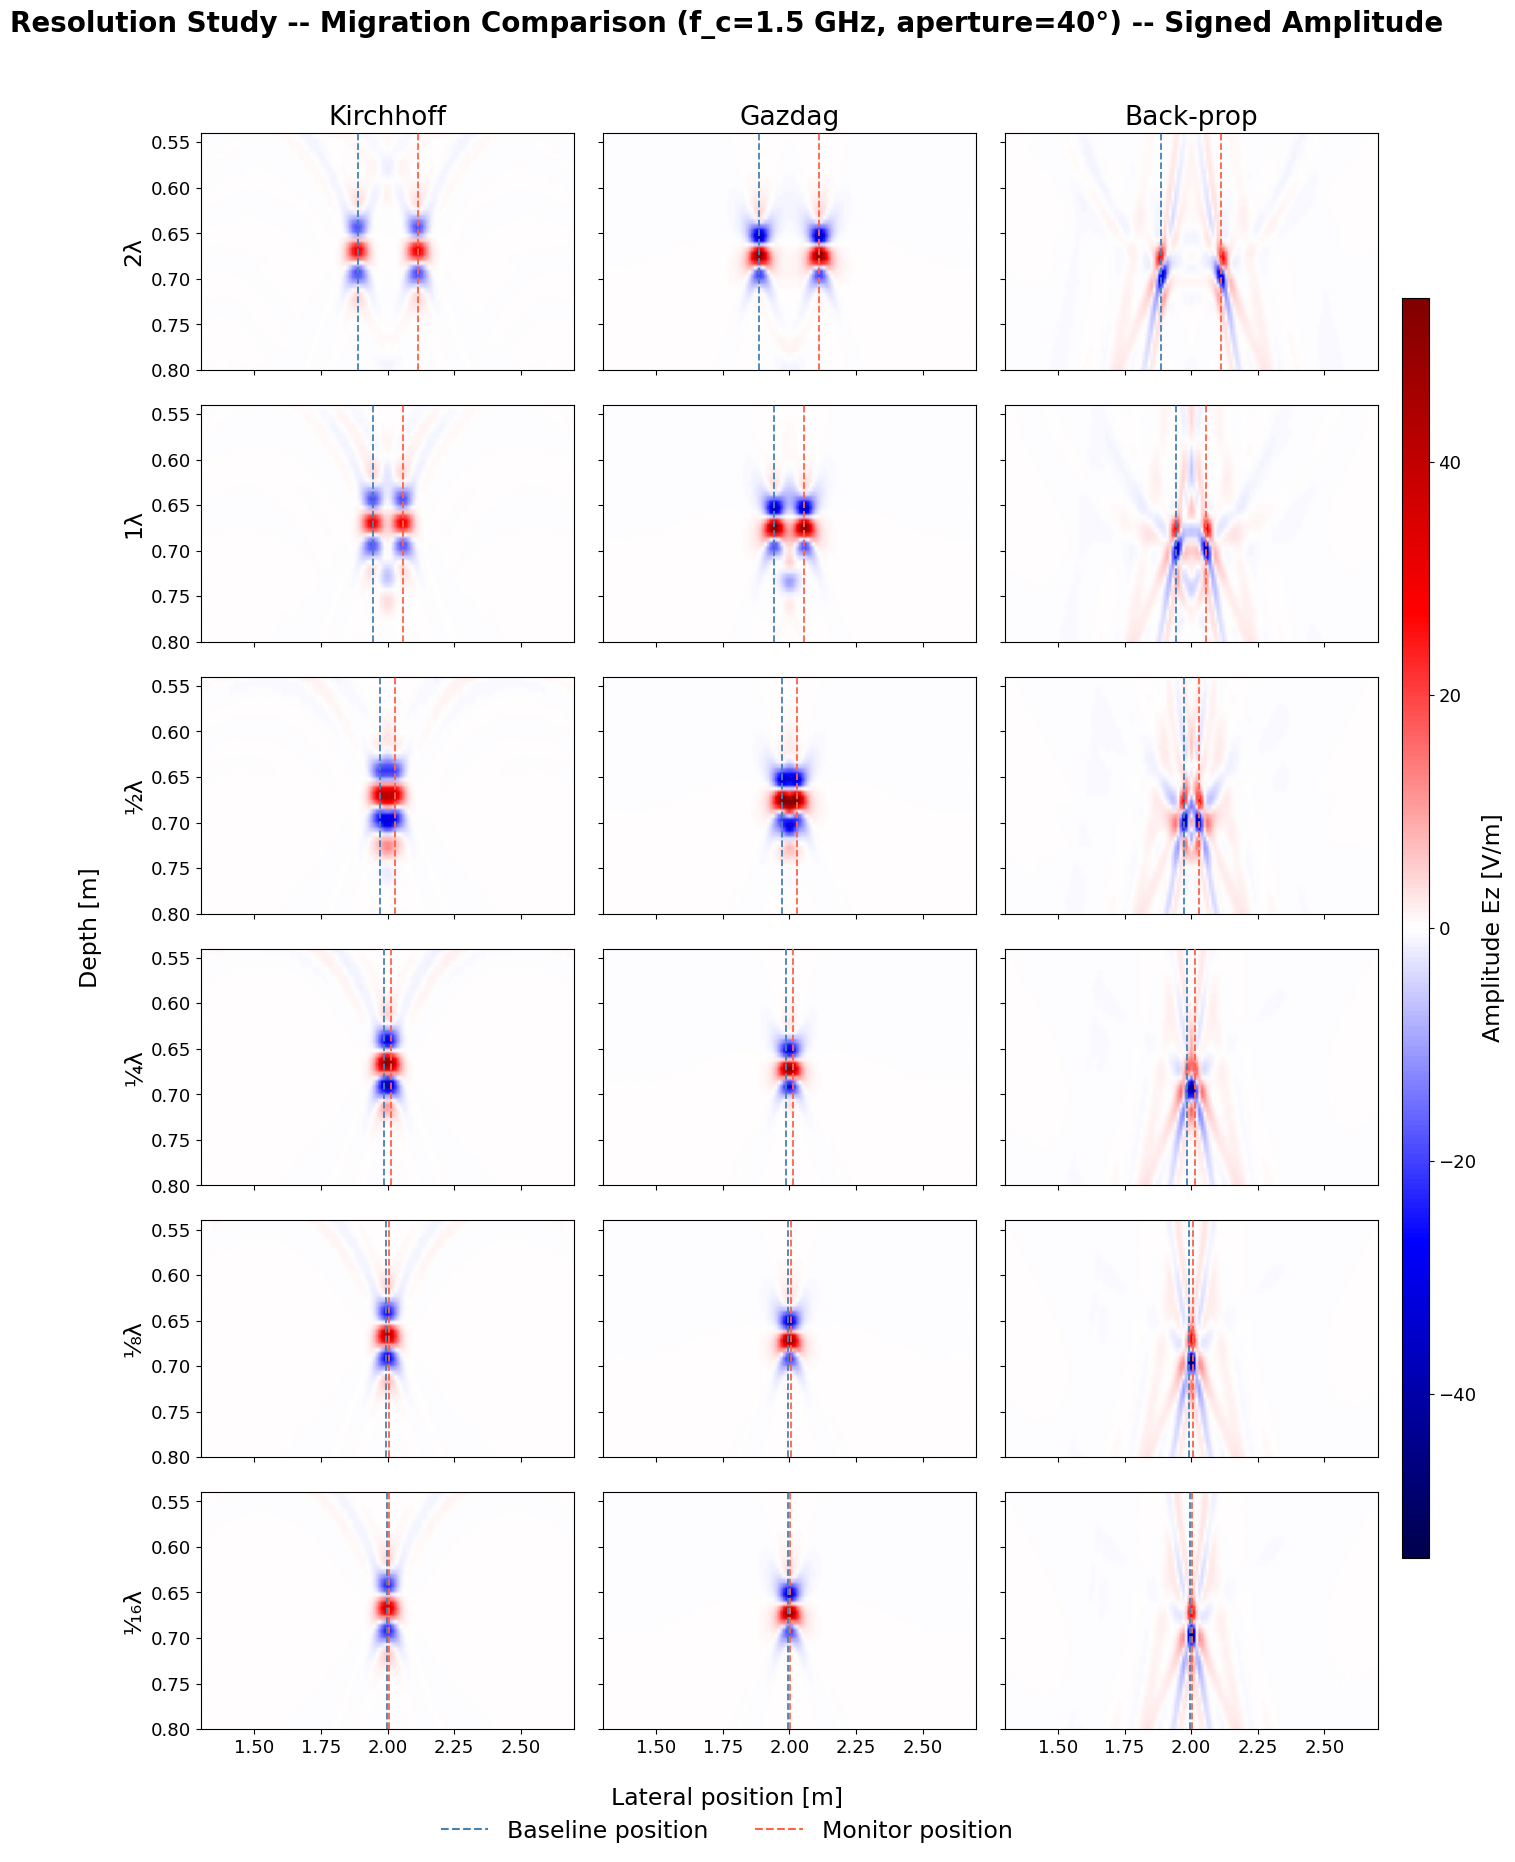

In [20]:
from scipy.signal import hilbert as scipy_hilbert
from scipy.interpolate import RegularGridInterpolator
import pyvista

# ── Collect images: rows = separations, cols = methods ───────────────────────
methods = ['Kirchhoff', 'Gazdag', 'Back-prop']
n_m, n_s = len(methods), len(labels)
imgs = [[None] * n_m for _ in range(n_s)]

for i, lbl in enumerate(labels):
    imgs[i][0] = migrated.get(lbl)
    imgs[i][1] = migrated_gz.get(lbl)

# Back-propagation — load all 6 datasets and reproject Ez to migration grid
# Back-prop snapshot grid: derive dimensions from first available VTI file
# (adapts automatically to dx=0.001 m or dx=0.002 m simulations)
Nx_bp, Ny_bp = None, None
for _slug in slugs:
    _snaps = sorted((STUDY_ROOT / "backprop" / _slug /
                     f"backprop_{_slug}_snaps").glob("bp_snap*.vti"),
                    key=lambda p: int(p.stem.replace("bp_snap", "")))
    if _snaps:
        _m0 = pyvista.read(str(_snaps[0]))
        Nx_bp = _m0.dimensions[0] - 1   # cells in x
        Ny_bp = _m0.dimensions[1] - 1   # cells in y
        break
assert Nx_bp is not None, "No back-prop snapshots found to derive grid dimensions"
x_ax_bp = np.linspace(0, 4.0, Nx_bp)   # gprMax x-axis (full domain)
y_ax_bp = np.linspace(0, 1.0, Ny_bp)   # gprMax y-axis (0=bottom, 1.0=top incl. air)
y_mig         = y_surface - z_img
Yq, Xq        = np.meshgrid(y_mig, x_traces, indexing='ij')
T_ns_bp       = n_t * dt_ns
t_focus_ns_bp = T_ns_bp - t0_ns
t_start_ns    = max(0.0, t_focus_ns_bp - SNAP_WIN)
dt_s          = dt_ns * 1e-9
snap_step_ref = max(1, int((T_ns_bp*1e-9 - t_start_ns*1e-9) / (max(1, N_SNAP - 1) * dt_s)))

for i, (lbl, slug) in enumerate(zip(labels, slugs)):
    snap_dir   = STUDY_ROOT / 'backprop' / slug / f'backprop_{slug}_snaps'
    snap_files = sorted(snap_dir.glob('bp_snap*.vti'),
                        key=lambda p: int(p.stem.replace('bp_snap', '')))
    if not snap_files:
        print(f'[{lbl}] No snapshots — skipping')
        continue

    snap_times_ns = t_start_ns + np.arange(len(snap_files)) * snap_step_ref * dt_ns
    idx_focus     = min(int(np.argmin(np.abs(snap_times_ns - t_focus_ns_bp))) + 4,
                        len(snap_files) - 1)

    snaps_ez = []
    for p in snap_files:
        mesh   = pyvista.read(str(p))
        e_data = np.array(mesh['E-field'])
        snaps_ez.append(e_data[:, 2].reshape(Ny_bp, Nx_bp))
    snaps_ez = np.stack(snaps_ez)

    interp_ez  = RegularGridInterpolator(
        (y_ax_bp, x_ax_bp), snaps_ez[idx_focus],
        method='linear', bounds_error=False, fill_value=0.0
    )
    imgs[i][2] = interp_ez((Yq, Xq))
    print(f'[{lbl}]  focus idx={idx_focus}  t={snap_times_ns[idx_focus]:.3f} ns')

# ── Scatterer depth coordinates ───────────────────────────────────────────────
# Migration: depth from surface  z_top = cylinder top
# Back-prop: gprMax domain 0-1.0 m; scatterer centre = 0.9 - y_scatterer
# Depth of scatterer centre from the ICE SURFACE (y_surface=0.9 m), not from the
# gprMax domain top (1.0 m).  Using 0.9 here is correct; 1.0 would give a depth
# 0.1 m too large (the air layer above the surface).
bp_z_top = 0.9 - y_scatterer   # = z_scatterer ≈ 0.676 m

# ── Shared plot helper ────────────────────────────────────────────────────────
extent_mig = [x_traces[0], x_traces[-1], z_img[-1], z_img[0]]
xlim = (1.3, 2.7)
ylim = (0.80, 0.54)

# ── Figure 1: signed amplitude ────────────────────────────────────────────────
# Larger fonts than plot_method_comparison_grid's module defaults, applied only for
# this call (then restored) since this figure is shrunk further than most in the
# thesis layout (fig:res-psf) and the default sizes were unreadably small there.
import helper_functions.visualisation as _viz
NEW_SUPTITLE_FS, NEW_TITLE_FS, NEW_LABEL_FS = 20, 19, 17
LEGEND_FS = 17
TICK_FS = 13
_orig_fs = (_viz.SUPTITLE_FONTSIZE, _viz.TITLE_FONTSIZE, _viz.LABEL_FONTSIZE)
_viz.SUPTITLE_FONTSIZE, _viz.TITLE_FONTSIZE, _viz.LABEL_FONTSIZE = NEW_SUPTITLE_FS, NEW_TITLE_FS, NEW_LABEL_FS

try:
    fig, axes = plot_method_comparison_grid(
        imgs, extent_mig, methods, labels, envelope=False, xlim=xlim, ylim=ylim,
        title=f'Resolution Study -- Migration Comparison (f_c={f_c_GHz} GHz, aperture={ANGLE_AP}°) -- Signed Amplitude',
    )
finally:
    _viz.SUPTITLE_FONTSIZE, _viz.TITLE_FONTSIZE, _viz.LABEL_FONTSIZE = _orig_fs

# No marker_x/marker_z passed above -- plot_method_comparison_grid only supports
# one single-point (star/triangle icon) reference per panel, not the pair of true
# scatterer positions this resolution test actually needs. Drawn here instead as
# two vertical dashed lines per panel (z-independent, so no back-prop-vs-migration
# depth-grid offset to juggle, unlike the old single-point marker_z did).
for i, ax_row in enumerate(axes):
    for ax in ax_row:
        ax.axvline(x_scatterer_1[i], color=COLOR_AMPLITUDE, lw=1.3, ls='--', zorder=6)
        ax.axvline(x_scatterer_2[i], color=COLOR_ENVELOPE, lw=1.3, ls='--', zorder=6)
        ax.tick_params(labelsize=TICK_FS)

marker_handles = [
    plt.Line2D([0], [0], color=COLOR_AMPLITUDE, lw=1.5, ls='--', label='Baseline position'),
    plt.Line2D([0], [0], color=COLOR_ENVELOPE, lw=1.5, ls='--', label='Monitor position'),
]
fig.legend(handles=marker_handles, loc='lower center', ncol=2, frameon=False,
           fontsize=LEGEND_FS, bbox_to_anchor=(0.5, -0.02))

fig.supxlabel('Lateral position [m]', fontsize=NEW_LABEL_FS)
fig.supylabel('Depth [m]', fontsize=NEW_LABEL_FS)

# plot_method_comparison_grid's suptitle unconditionally appends "★ = baseline,
# ▲ = timelapsed" -- meaningless here (no icons are drawn at all any more, and
# there's no timelapse/baseline-monitor-displacement concept in a static
# two-scatterer resolution test), so overwrite it with the plain title.
fig.suptitle(
    f'Resolution Study -- Migration Comparison (f_c={f_c_GHz} GHz, aperture={ANGLE_AP}°) -- Signed Amplitude',
    fontsize=NEW_SUPTITLE_FS, fontweight='bold', y=1.01)
# Add shared colorbar below the figure
cbar_ax = fig.add_axes([1, 0.15, 0.02, 0.7])
cbar = fig.colorbar(axes[0, 0].images[0], cax=cbar_ax, orientation='vertical')
cbar.set_label('Amplitude Ez [V/m]', fontsize=NEW_LABEL_FS)
cbar.ax.tick_params(labelsize=TICK_FS)
fig.tight_layout()
plt.show()

  [saved] Resolution_Study\General\RES_017_Resolution_Study_--_PSF_Zoom_Baseline_vs_Monitor.png


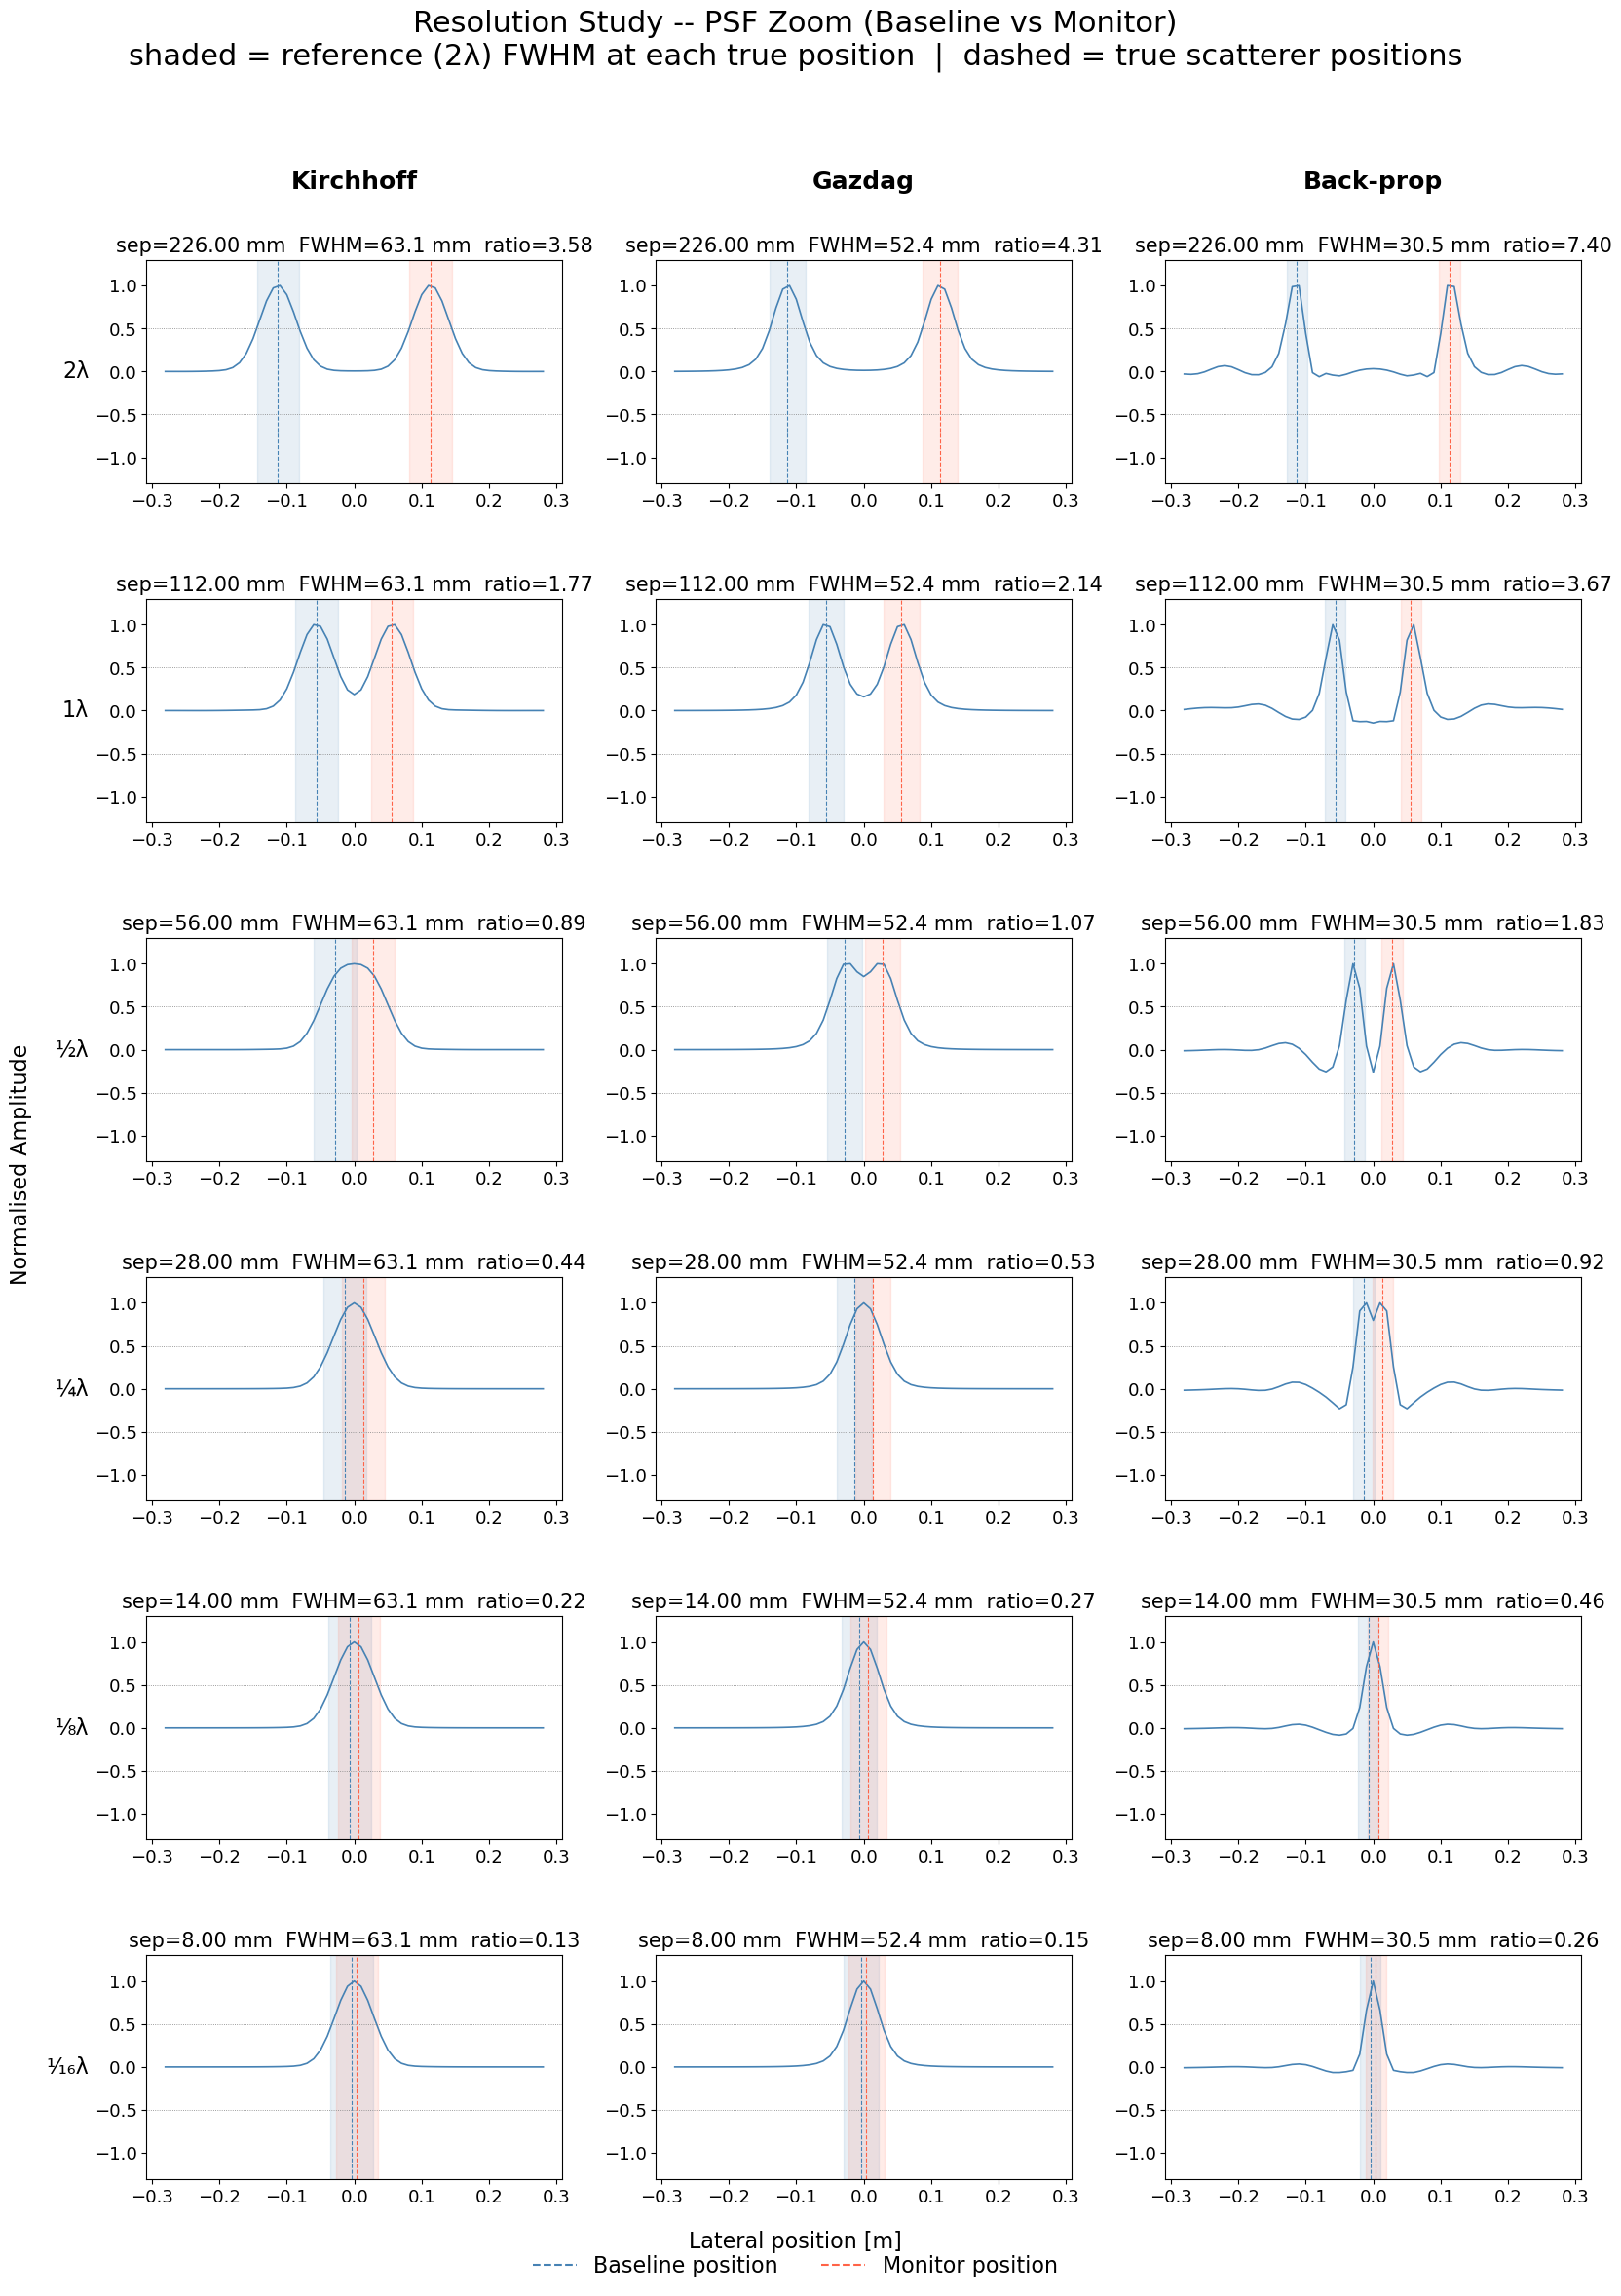

In [21]:
# ── Zoomed two-scatterer PSF grid (resolution study) ──────────────────────────
# Same visual style as Hypothesis_1.ipynb's plot_amplitude_zoom / run_amplitude_test:
# peak-normalised profile, shaded FWHM band(s), dashed true-position markers, and a
# sep/FWHM/ratio title per panel. Unlike Hypothesis_1's Baseline-vs-Monitor time-lapse
# pair, this study has no displaced pair -- each separation scenario is a single
# static two-scatterer image -- so the reference FWHM is instead measured once per
# method from the isolated left scatterer of the widest (2*lambda) scenario, where it
# is far enough from the right scatterer not to be contaminated by its sidelobe, and
# that same FWHM is then shaded around BOTH true scatterer positions in every panel.
from helper_functions.visualisation import (
    COLOR_AMPLITUDE, COLOR_ENVELOPE, PLACEHOLDER_FACECOLOR, PLACEHOLDER_TEXT_COLOR,
    SUPTITLE_FONTSIZE, TITLE_FONTSIZE, LABEL_FONTSIZE, TICK_FONTSIZE,
)

# Larger fonts than the module defaults for this figure only (local names, does not
# affect any other cell/notebook) -- this grid is shrunk further than most in the
# thesis layout (fig:res-psf) and the default sizes were unreadably small there.
SUPTITLE_FONTSIZE, TITLE_FONTSIZE, LABEL_FONTSIZE, TICK_FONTSIZE = 22, 15, 16, 13
# Column ("Kirchhoff"/"Gazdag"/"Back-prop") headers -- kept as its own constant
# (not tied to SUPTITLE_FONTSIZE) and bumped only slightly: these sit close above
# each top-row panel's own per-panel title, and a bigger jump starts overlapping it.
HEADER_FONTSIZE = 18


def fwhm_1d(profile, axis_vals):
    """Full Width at Half Maximum of a single-lobed profile around its (possibly
    negative-polarity) peak, with linear interpolation across the half-max crossing on
    each side for sub-sample accuracy. Returns (fwhm, x_left, x_right, x_peak)."""
    amp = np.abs(profile)
    peak_idx = int(np.argmax(amp))
    half = amp[peak_idx] / 2.0

    i = peak_idx
    while i > 0 and amp[i] > half:
        i -= 1
    x_left = axis_vals[i] if i == peak_idx else np.interp(
        half, [amp[i], amp[i + 1]], [axis_vals[i], axis_vals[i + 1]])

    i = peak_idx
    while i < len(amp) - 1 and amp[i] > half:
        i += 1
    x_right = axis_vals[i] if i == peak_idx else np.interp(
        half, [amp[i], amp[i - 1]], [axis_vals[i], axis_vals[i - 1]])

    return abs(x_right - x_left), x_left, x_right, axis_vals[peak_idx]


half_window_lam = 2.5
hw = half_window_lam * wavelength

# Reference FWHM per method: isolated left scatterer, widest (2*lambda) scenario.
fwhm_ref = {}
for j, method in enumerate(methods):
    ref_img = imgs[0][j]
    if ref_img is None:
        fwhm_ref[method] = np.nan
        continue
    marker_z_ref = bp_z_top if j == 2 else z_top
    iz_ref = int(np.argmin(np.abs(z_img - marker_z_ref)))
    mask_ref = (x_traces >= x_scatterer_1[0] - hw) & (x_traces <= x_scatterer_1[0] + hw)
    axis_vals_ref = x_traces[mask_ref] - x_scatterer_1[0]
    profile_ref = ref_img[iz_ref, mask_ref]
    peak_ref = np.max(np.abs(profile_ref))
    profile_ref_n = profile_ref / peak_ref if peak_ref > 0 else profile_ref
    fwhm_ref[method], _, _, _ = fwhm_1d(profile_ref_n, axis_vals_ref)

fig, axes = plt.subplots(n_s, n_m, figsize=(5.6 * n_m, 3.8 * n_s), squeeze=False)
for j, method in enumerate(methods):
    fwhm = fwhm_ref[method]
    marker_z = bp_z_top if j == 2 else z_top
    iz = int(np.argmin(np.abs(z_img - marker_z)))
    for i, lbl in enumerate(labels):
        ax = axes[i, j]
        img = imgs[i][j]
        centre = 0.5 * (x_scatterer_1[i] + x_scatterer_2[i])
        mask = (x_traces >= centre - hw) & (x_traces <= centre + hw)
        axis_vals = x_traces[mask] - centre
        if img is None:
            ax.text(0.5, 0.5, 'N/A', transform=ax.transAxes, ha='center', va='center',
                    color=PLACEHOLDER_TEXT_COLOR)
            ax.set_facecolor(PLACEHOLDER_FACECOLOR)
            ax.tick_params(labelsize=TICK_FONTSIZE)
        else:
            profile = img[iz, mask]
            peak = np.max(np.abs(profile))
            profile_n = profile / peak if peak > 0 else profile
            sep_mm = abs(x_scatterer_2[i] - x_scatterer_1[i]) * 1e3
            ratio = sep_mm / (fwhm * 1e3) if fwhm > 0 else np.nan

            x_s1_rel = x_scatterer_1[i] - centre
            x_s2_rel = x_scatterer_2[i] - centre
            ax.plot(axis_vals, profile_n, color=COLOR_AMPLITUDE, lw=1.2)
            ax.axhline(0.5, color='grey', lw=0.6, ls=':')
            ax.axhline(-0.5, color='grey', lw=0.6, ls=':')
            ax.axvspan(x_s1_rel - fwhm / 2, x_s1_rel + fwhm / 2, color=COLOR_AMPLITUDE, alpha=0.12)
            ax.axvspan(x_s2_rel - fwhm / 2, x_s2_rel + fwhm / 2, color=COLOR_ENVELOPE, alpha=0.12)
            ax.axvline(x_s1_rel, color=COLOR_AMPLITUDE, lw=0.8, ls='--')
            ax.axvline(x_s2_rel, color=COLOR_ENVELOPE, lw=0.8, ls='--')
            ax.set_ylim(-1.3, 1.3)
            ax.set_title(f'sep={sep_mm:.2f} mm  FWHM={fwhm*1e3:.1f} mm  ratio={ratio:.2f}',
                         fontsize=TITLE_FONTSIZE)
            ax.tick_params(labelsize=TICK_FONTSIZE)
        if i == 0:
            ax.text(0.5, 1.32, method, transform=ax.transAxes, ha='center',
                    fontsize=HEADER_FONTSIZE, fontweight='bold')
        if j == 0:
            ax.set_ylabel(lbl, fontsize=LABEL_FONTSIZE, rotation=0, ha='right', va='center')

fig.suptitle('Resolution Study -- PSF Zoom (Baseline vs Monitor)\n'
             'shaded = reference (2λ) FWHM at each true position  |  '
             'dashed = true scatterer positions', fontsize=SUPTITLE_FONTSIZE, y=1.02)

# Same baseline/monitor legend as the migration-comparison grid (fig:res-psf (a)),
# reusing the same colour convention this cell's own axvline/axvspan calls already use.
marker_handles = [
    plt.Line2D([0], [0], color=COLOR_AMPLITUDE, lw=1.5, ls='--', label='Baseline position'),
    plt.Line2D([0], [0], color=COLOR_ENVELOPE, lw=1.5, ls='--', label='Monitor position'),
]
fig.legend(handles=marker_handles, loc='lower center', ncol=2, frameon=False,
           fontsize=LABEL_FONTSIZE, bbox_to_anchor=(0.5, -0.01))

fig.supxlabel('Lateral position [m]', fontsize=LABEL_FONTSIZE)
fig.supylabel('Normalised Amplitude', fontsize=LABEL_FONTSIZE)

fig.tight_layout(h_pad=3.0, w_pad=1.5)
plt.show()

# Save Migrated Results as np arrays dictionary

In [ ]:
# ── Save normal migrated results from all methods ────────────────────────────
# Reads directly from migrated, migrated_gz, and focus_frames (back-prop).
#   scenarios = labels   →  ["2λ", "1λ", "½λ", "¼λ", "⅛λ", "¹⁄₁₆λ"]
#   methods              →  ["Kirchhoff", "Gazdag", "LSM (CGLS)", "Back-prop"]
#   each image: shape (n_z, n_x) on the z_img × x_traces grid
#   LSM (CGLS) was run for the 2λ scenario only — None elsewhere.

# ── Kirchhoff & Gazdag: direct stack over labels ──────────────────────────────
kirchhoff_all = np.stack([migrated[lbl].astype(float)    for lbl in labels], axis=0)  # (6, n_z, n_x)
gazdag_all    = np.stack([migrated_gz[lbl].astype(float) for lbl in labels], axis=0)

# ── Back-prop: reproject focus_frames ez onto migration grid ──────────────────
_ref_shape = kirchhoff_all.shape[1:]
x_ax_bp = np.linspace(0, 4.0, Nx_bp)
y_ax_bp = np.linspace(0, 1.0, Ny_bp)
y_mig   = y_surface - z_img
Yq, Xq  = np.meshgrid(y_mig, x_traces, indexing='ij')

from scipy.interpolate import RegularGridInterpolator as _RGI
backprop_planes = []
for lbl in labels:
    if lbl in focus_frames:
        interp = _RGI((y_ax_bp, x_ax_bp), focus_frames[lbl]['ez'],
                      method='linear', bounds_error=False, fill_value=0.0)
        backprop_planes.append(interp((Yq, Xq)).astype(float))
    else:
        backprop_planes.append(np.full(_ref_shape, np.nan))
        print(f'[{lbl}] focus_frames missing — filled with NaN')
backprop_all = np.stack(backprop_planes, axis=0)  # (6, n_z, n_x)

lsm_cgls_2lam = imgs[0][2].astype(float) if imgs[0][2] is not None else None

# ── Save to disk ──────────────────────────────────────────────────────────────
save_path = STUDY_ROOT / "migrated_results.npz"

payload = dict(
    kirchhoff         = kirchhoff_all,                                  # (6, n_z, n_x)
    gazdag            = gazdag_all,
    backprop          = backprop_all,
    scenarios         = np.array(labels,  dtype="U20"),                 # (6,)  string
    methods           = np.array(methods, dtype="U20"),                 # (4,)  string
    separation_lambda = np.array([2, 1, 0.5, 0.25, 0.125, 0.0625]),    # (6,)  float
    x_traces          = x_traces,                                       # (n_x,) m
    z_img             = z_img,                                          # (n_z,) m
    x_s1              = np.array(x_scatterer_1),                        # (6,) m  left-scatterer x
    x_s2              = np.array(x_scatterer_2),                        # (6,) m  right-scatterer x
    z_scatterer       = np.float64(z_scatterer),
    z_top             = np.float64(z_top),
)
if lsm_cgls_2lam is not None:
    payload["lsm_cgls_2lambda"] = lsm_cgls_2lam   # (n_z, n_x) — 2λ only

np.savez_compressed(save_path, **payload)

# ── In-memory convenience dict ────────────────────────────────────────────────
mig = {
    "Kirchhoff": {lbl: kirchhoff_all[i] for i, lbl in enumerate(labels)},
    "Gazdag":    {lbl: gazdag_all[i]    for i, lbl in enumerate(labels)},
    "Back-prop": {lbl: backprop_all[i]  for i, lbl in enumerate(labels)},
}
if lsm_cgls_2lam is not None:
    mig["LSM (CGLS)"] = {labels[0]: lsm_cgls_2lam}

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"Saved → {save_path}")
print(f"\nStacked arrays  (n_scenarios={len(labels)}, n_z={_ref_shape[0]}, n_x={_ref_shape[1]}):")
for name, arr in [("kirchhoff",  kirchhoff_all),
                  ("gazdag",     gazdag_all),
                  ("backprop",   backprop_all)]:
    absent = int(np.isnan(arr).all(axis=(1, 2)).sum())
    note   = f"  ({absent} scenario(s) absent → NaN)" if absent else ""
    print(f"  {name:<12}  {arr.shape}{note}")
if lsm_cgls_2lam is not None:
    print(f"  lsm_cgls      {lsm_cgls_2lam.shape}  (2λ only)")

print(f"\nAvailability  ✓ = computed   — = not run")
col_w = 14
print("  " + f"{'':>8}  " + "".join(f"{m:>{col_w}}" for m in methods))
for i, lbl in enumerate(labels):
    row = "  " + f"{lbl:>8}  "
    row += "".join(f"{'✓':>{col_w}}" if imgs[i][j] is not None else f"{'—':>{col_w}}"
                   for j in range(n_m))
    print(row)

print(f"\nUsage examples:")
print(f"  d = np.load(str(STUDY_ROOT / 'migrated_results.npz'), allow_pickle=False)")
print(f"  d['kirchhoff'][0]   # Kirchhoff 2λ  → shape (n_z, n_x)")
print(f"  d['gazdag'][3]      # Gazdag    ¼λ  → shape (n_z, n_x)")


# Conceptual Schematic — Phase-Plane Method Pipeline

In [ ]:
# ── Conceptual schematic: the 2D phase-plane shift-estimation pipeline ───
# Illustrative only (synthetic toy scatterer, not simulation data): shows the
# baseline/monitor images, their cross-spectrum, and the WLS phase-plane fit
# that recovers a sub-wavelength displacement (Theory chapter, sec:th-wls).
from numpy.fft import fft2, fftshift, fftfreq
from helper_functions.visualisation import (
    CMAP_SIGNED, COLOR_AMPLITUDE, COLOR_ENVELOPE, SUPTITLE_FONTSIZE,
    TITLE_FONTSIZE, LABEL_FONTSIZE, TICK_FONTSIZE, LEGEND_FONTSIZE,
)

nz, nx = 128, 128
z_ax = np.linspace(0, 1.0, nz)
x_ax = np.linspace(0, 1.0, nx)
Z, X = np.meshgrid(z_ax, x_ax, indexing='ij')

lam_toy = 0.12                       # illustrative wavelength [m]
z0, x0 = 0.5, 0.5                    # baseline target position
sigma = 0.06

def _blob(zc, xc):
    r2 = (Z - zc) ** 2 + (X - xc) ** 2
    envelope = np.exp(-r2 / (2 * sigma ** 2))
    carrier = np.cos(2 * np.pi * np.sqrt(r2) / lam_toy)
    return envelope * carrier

dz_true, dx_true = lam_toy / 12, lam_toy / 12   # a genuinely sub-wavelength shift
baseline_img = _blob(z0, x0)
monitor_img  = _blob(z0 + dz_true, x0 + dx_true)

# Cross-spectrum: FFT2(monitor) * conj(FFT2(baseline)) — Fourier shift theorem
F_base = fft2(baseline_img)
F_mon  = fft2(monitor_img)
cross_spec = F_mon * np.conj(F_base)
phase = np.angle(fftshift(cross_spec))

kz = fftshift(fftfreq(nz, d=(z_ax[1] - z_ax[0]))) * 2 * np.pi
kx = fftshift(fftfreq(nx, d=(x_ax[1] - x_ax[0]))) * 2 * np.pi

# WLS fit of the phase plane: phase(kz,kx) ≈ -(dz*kz + dx*kx), amplitude-weighted
weights = np.abs(fftshift(cross_spec))
mask = weights > 0.15 * weights.max()
Kz, Kx = np.meshgrid(kz, kx, indexing='ij')
A = np.column_stack([Kz[mask], Kx[mask], np.ones(mask.sum())])
w = weights[mask]
sol, *_ = np.linalg.lstsq(A * w[:, None], phase[mask] * w, rcond=None)
dz_est, dx_est = -sol[0], -sol[1]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

ax = axes[0]
ax.imshow(baseline_img, extent=[x_ax[0], x_ax[-1], z_ax[-1], z_ax[0]],
          cmap=CMAP_SIGNED, vmin=-1, vmax=1, aspect='auto')
ax.set_title('(a) Baseline image', fontsize=TITLE_FONTSIZE)
ax.set_xlabel('x [m]', fontsize=LABEL_FONTSIZE)
ax.set_ylabel('z [m]', fontsize=LABEL_FONTSIZE)
ax.tick_params(labelsize=TICK_FONTSIZE)

ax = axes[1]
ax.imshow(monitor_img, extent=[x_ax[0], x_ax[-1], z_ax[-1], z_ax[0]],
          cmap=CMAP_SIGNED, vmin=-1, vmax=1, aspect='auto')
ax.set_title('(b) Monitor image\n(sub-wavelength shift)', fontsize=TITLE_FONTSIZE)
ax.set_xlabel('x [m]', fontsize=LABEL_FONTSIZE)
ax.tick_params(labelsize=TICK_FONTSIZE)

ax = axes[2]
ax.imshow(phase, extent=[kx[0], kx[-1], kz[-1], kz[0]],
          cmap=CMAP_SIGNED, vmin=-np.pi, vmax=np.pi, aspect='auto')
ax.set_title('(c) Cross-spectrum phase\n(linear ramp)', fontsize=TITLE_FONTSIZE)
ax.set_xlabel(r'$k_x$ [rad/m]', fontsize=LABEL_FONTSIZE)
ax.set_ylabel(r'$k_z$ [rad/m]', fontsize=LABEL_FONTSIZE)
ax.tick_params(labelsize=TICK_FONTSIZE)

ax = axes[3]
kz0_idx = np.argmin(np.abs(kz))
ax.plot(kx, phase[kz0_idx], '.', color=COLOR_AMPLITUDE, ms=3, label='cross-spectrum phase')
fit_line = -(dz_est * kz[kz0_idx] + dx_est * kx)
ax.plot(kx, fit_line, '-', color=COLOR_ENVELOPE, lw=1.5, label='WLS plane fit')
ax.set_title('(d) WLS phase-plane fit\n' +
             rf'$\Delta x$ recovered = {dx_est*1000:.3f} mm (true {dx_true*1000:.3f} mm)',
             fontsize=TITLE_FONTSIZE)
ax.set_xlabel(r'$k_x$ [rad/m]', fontsize=LABEL_FONTSIZE)
ax.set_ylabel('phase [rad]', fontsize=LABEL_FONTSIZE)
ax.legend(fontsize=LEGEND_FONTSIZE)
ax.tick_params(labelsize=TICK_FONTSIZE)

fig.suptitle('Phase-Plane Method — Conceptual Workflow', fontsize=SUPTITLE_FONTSIZE)
fig.tight_layout()
plt.show()
